In [1]:
"""
Master Model Experiments
========================
Comprehensive experiments using the unified SEIXHRD model with:
- Exposed (E) compartment for latent period dynamics
- Separate Ward/ICU compartments with capacity constraints
- Differential mortality tracking
- Seasonal forcing of transmission
- Policy interventions (lockdowns)
- Waning immunity

This notebook demonstrates the full capabilities of the master hospital model.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Import model and utilities
import sys
from pathlib import Path

# Add parent directory to path if needed
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

from master_hospital_model import simulate_master_hospital_model
from plotting_utils import (
    plot_age_structured_icu_results, 
    plot_age_structured_icu_full,
    PlotConfig
)
import config

# Set up plotting style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("✓ All modules loaded successfully")
print(f"✓ Using {'empirical' if config.USE_EMPIRICAL_PARAMS else 'teaching'} parameters")

✓ All modules loaded successfully
✓ Using empirical parameters


# Experiment 1: Baseline Simulation with All Features

Run a baseline simulation using the master model with realistic parameters to establish a reference point for comparisons.

In [2]:
# ============================================
# Experiment 1: Baseline Master Model Run
# ============================================

# Use regional population scale for meaningful hospital capacity dynamics
age_pops = config.AGE_POPS_REGIONAL_DEFAULT  # [60000, 100000, 40000] = 200,000 total
ward_capacity = config.REGIONAL_CAPACITY_PARAMS['ward_capacity']  # 1600
icu_capacity = config.REGIONAL_CAPACITY_PARAMS['icu_capacity']     # 400

# Run baseline simulation (no interventions, no seasonality, no waning)
baseline_results = simulate_master_hospital_model(
    beta_base=0.25,
    age_params=config.AGE_PARAMS_DEFAULT,
    contact_matrix=config.CONTACT_MATRIX_DEFAULT,
    ward_capacity=ward_capacity,
    icu_capacity=icu_capacity,
    coverage=[0.3, 0.4, 0.7],  # Age-targeted vaccination
    VE=0.7,
    age_pops=age_pops,
    Tmax=300,
    track_differential_mortality=True
)

# Quick summary
total_deaths = sum(baseline_results['D'][a][-1] for a in range(3))
peak_ward = max(baseline_results['H_ward_total'])
peak_icu = max(baseline_results['H_icu_total'])

print("="*60)
print("BASELINE SIMULATION RESULTS")
print("="*60)
print(f"Population: {sum(age_pops):,}")
print(f"Simulation duration: 300 days")
print(f"\nHospital Capacity:")
print(f"  Ward: {ward_capacity} beds")
print(f"  ICU: {icu_capacity} beds")
print(f"\nPeak Occupancy:")
print(f"  Ward: {peak_ward:.0f} ({peak_ward/ward_capacity*100:.1f}% of capacity)")
print(f"  ICU: {peak_icu:.0f} ({peak_icu/icu_capacity*100:.1f}% of capacity)")
print(f"\nMortality:")
print(f"  Total deaths: {total_deaths:.0f}")
print(f"  Treated deaths: {baseline_results['D_treated_total'][-1]:.0f}")
print(f"  Untreated (preventable): {baseline_results['D_untreated_total'][-1]:.0f}")

BASELINE SIMULATION RESULTS
Population: 200,000
Simulation duration: 300 days

Hospital Capacity:
  Ward: 1600 beds
  ICU: 400 beds

Peak Occupancy:
  Ward: 2509 (156.8% of capacity)
  ICU: 627 (156.7% of capacity)

Mortality:
  Total deaths: 15450
  Treated deaths: 4151
  Untreated (preventable): 11299


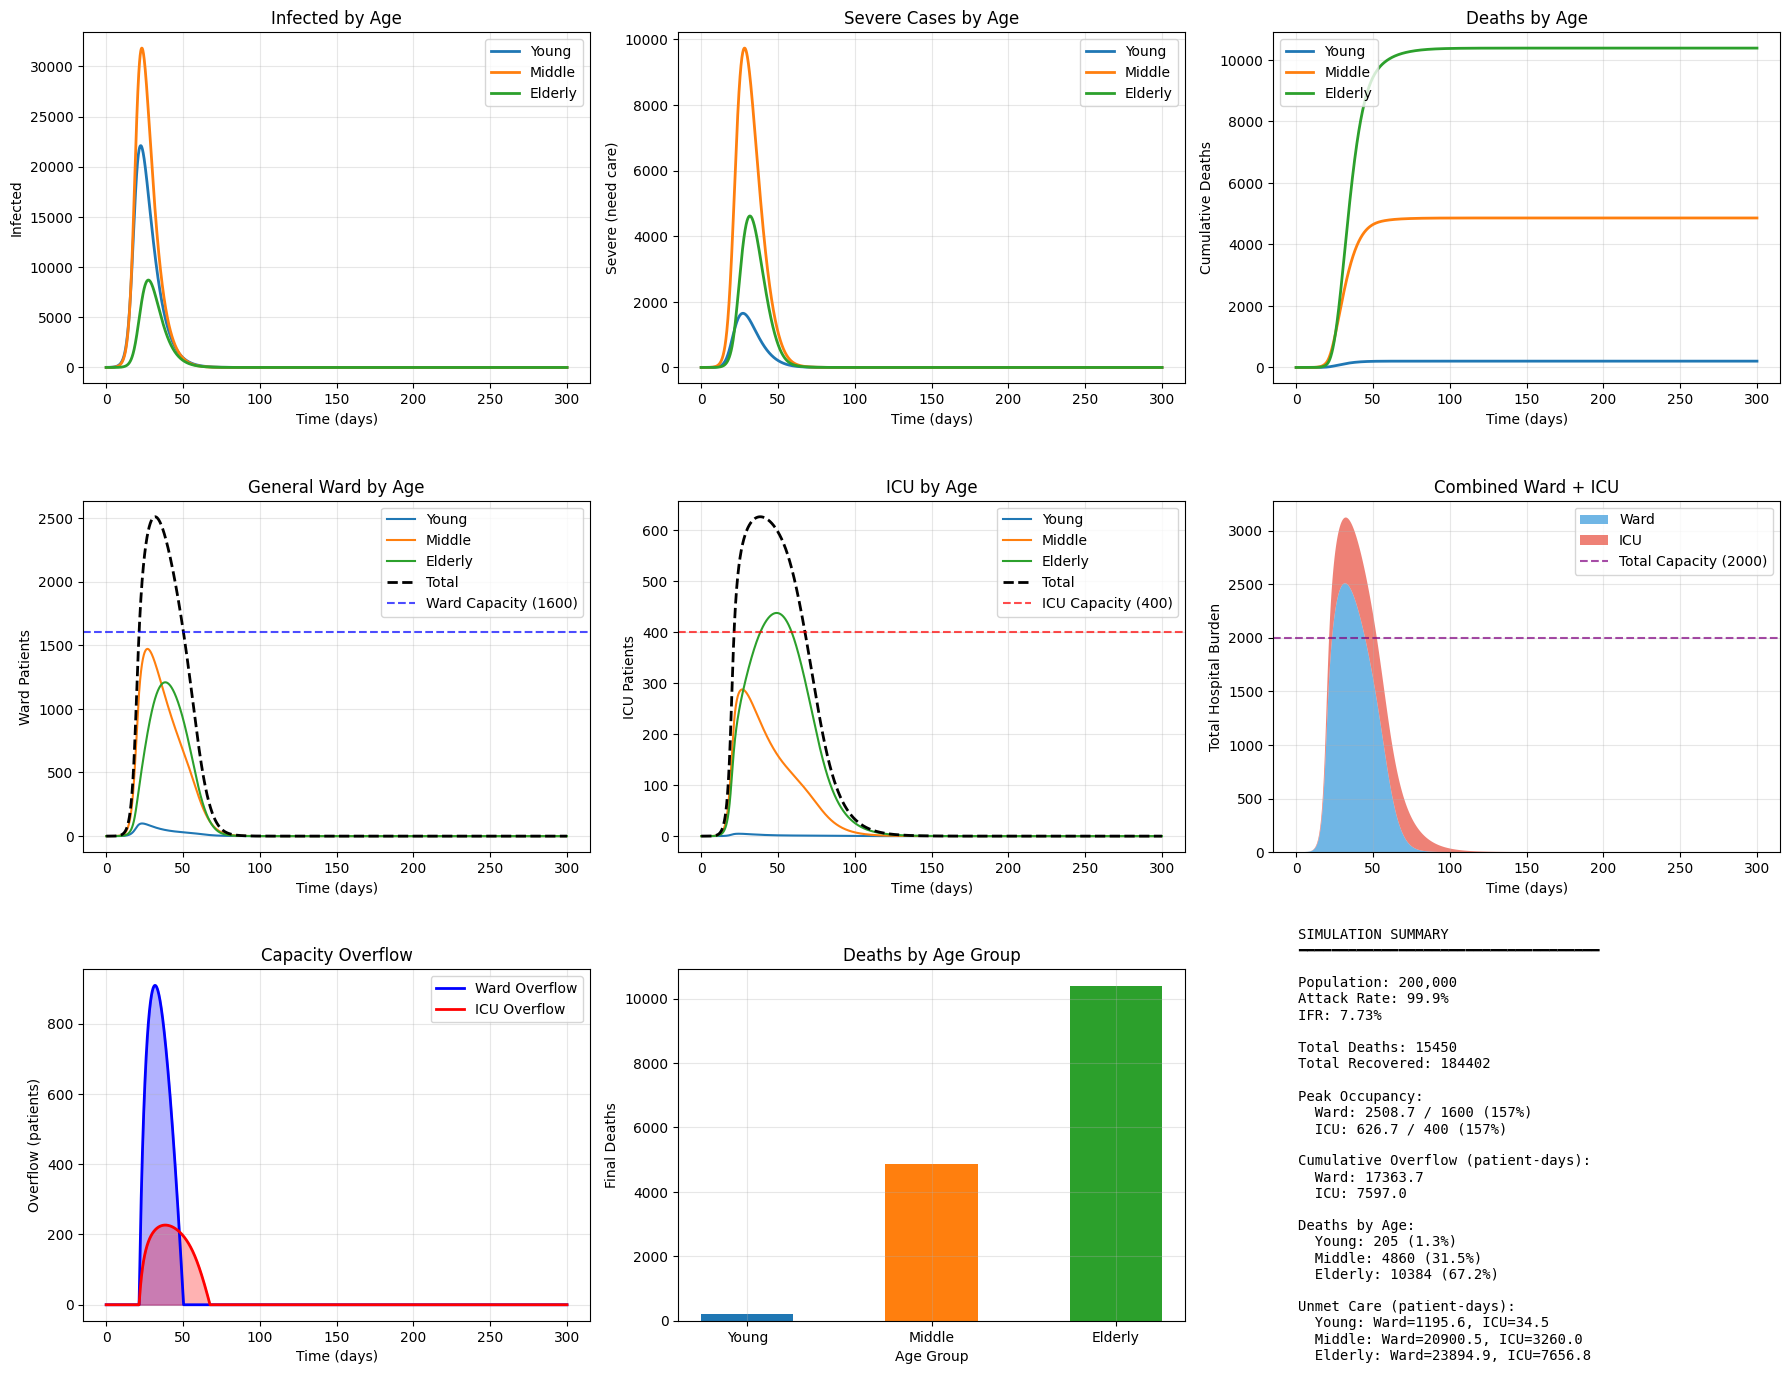

In [3]:
# Visualize baseline results with full compartment view
fig, axes = plot_age_structured_icu_results(
    baseline_results,
    age_labels=config.AGE_LABELS_SHORT,
    show=True,
    verbose=False
)

# Experiment 2: Impact of Policy Interventions (Lockdowns)

Compare epidemic outcomes with and without lockdown policies. This demonstrates how the model captures the effect of non-pharmaceutical interventions.

In [4]:
# ============================================
# Experiment 2: Policy Intervention Comparison
# ============================================

# Define intervention scenarios
scenarios = {
    'No intervention': [],
    'Early lockdown (day 30-60)': [
        {'start_day': 30, 'end_day': 60, 'transmission_reduction': 0.5}
    ],
    'Late lockdown (day 60-90)': [
        {'start_day': 60, 'end_day': 90, 'transmission_reduction': 0.5}
    ],
    'Strong lockdown (60% reduction)': [
        {'start_day': 40, 'end_day': 80, 'transmission_reduction': 0.6}
    ],
    'Multiple waves (two lockdowns)': [
        {'start_day': 30, 'end_day': 50, 'transmission_reduction': 0.5},
        {'start_day': 120, 'end_day': 150, 'transmission_reduction': 0.4}
    ]
}

# Run all scenarios
policy_results = {}
for name, interventions in scenarios.items():
    policy_results[name] = simulate_master_hospital_model(
        beta_base=0.25,
        age_params=config.AGE_PARAMS_DEFAULT,
        contact_matrix=config.CONTACT_MATRIX_DEFAULT,
        ward_capacity=ward_capacity,
        icu_capacity=icu_capacity,
        coverage=[0.3, 0.4, 0.7],
        VE=0.7,
        age_pops=age_pops,
        interventions=interventions,
        Tmax=300,
        track_differential_mortality=True
    )

# Compare results
print("="*80)
print("POLICY INTERVENTION COMPARISON")
print("="*80)
print(f"{'Scenario':<35} {'Deaths':>10} {'Peak Ward':>12} {'Peak ICU':>10} {'Prevented':>12}")
print("-"*80)

baseline_deaths = sum(policy_results['No intervention']['D'][a][-1] for a in range(3))
for name, res in policy_results.items():
    deaths = sum(res['D'][a][-1] for a in range(3))
    peak_w = max(res['H_ward_total'])
    peak_i = max(res['H_icu_total'])
    prevented = baseline_deaths - deaths
    print(f"{name:<35} {deaths:>10.0f} {peak_w:>12.0f} {peak_i:>10.0f} {prevented:>12.0f}")

POLICY INTERVENTION COMPARISON
Scenario                                Deaths    Peak Ward   Peak ICU    Prevented
--------------------------------------------------------------------------------
No intervention                          15450         2509        627            0
Early lockdown (day 30-60)               15335         2509        626          115
Late lockdown (day 60-90)                15449         2509        627            1
Strong lockdown (60% reduction)          15427         2509        627           22
Multiple waves (two lockdowns)           15344         2509        626          106


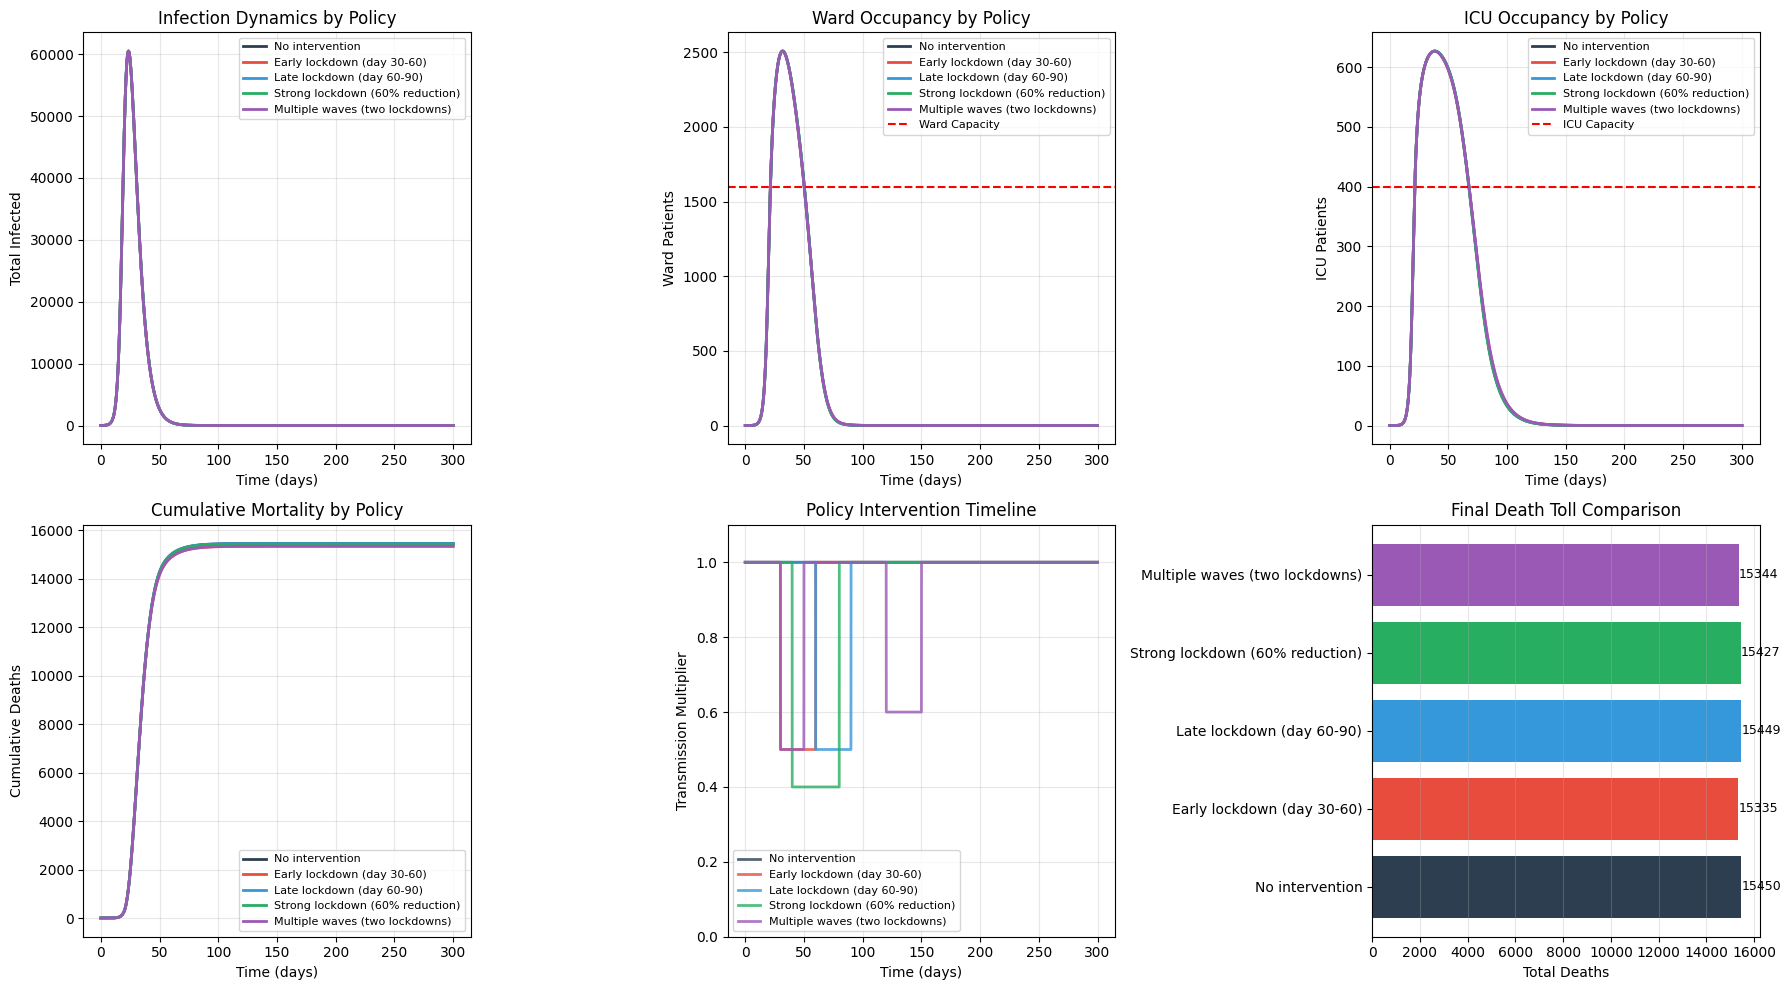

In [5]:
# Visualize policy intervention effects
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

colors = ['#2c3e50', '#e74c3c', '#3498db', '#27ae60', '#9b59b6']
times = policy_results['No intervention']['times']

# Plot 1: Infected over time
ax = axes[0, 0]
for i, (name, res) in enumerate(policy_results.items()):
    I_total = [sum(res['I'][a][t] for a in range(3)) for t in range(len(times))]
    ax.plot(times, I_total, label=name, color=colors[i], linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Total Infected')
ax.set_title('Infection Dynamics by Policy')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: Hospital ward occupancy
ax = axes[0, 1]
for i, (name, res) in enumerate(policy_results.items()):
    ax.plot(times, res['H_ward_total'], label=name, color=colors[i], linewidth=2)
ax.axhline(y=ward_capacity, color='red', linestyle='--', label='Ward Capacity')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Ward Patients')
ax.set_title('Ward Occupancy by Policy')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 3: ICU occupancy
ax = axes[0, 2]
for i, (name, res) in enumerate(policy_results.items()):
    ax.plot(times, res['H_icu_total'], label=name, color=colors[i], linewidth=2)
ax.axhline(y=icu_capacity, color='red', linestyle='--', label='ICU Capacity')
ax.set_xlabel('Time (days)')
ax.set_ylabel('ICU Patients')
ax.set_title('ICU Occupancy by Policy')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 4: Cumulative deaths
ax = axes[1, 0]
for i, (name, res) in enumerate(policy_results.items()):
    D_total = [sum(res['D'][a][t] for a in range(3)) for t in range(len(times))]
    ax.plot(times, D_total, label=name, color=colors[i], linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Cumulative Deaths')
ax.set_title('Cumulative Mortality by Policy')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 5: Policy multiplier over time
ax = axes[1, 1]
for i, (name, res) in enumerate(policy_results.items()):
    ax.plot(times, res['policy_mult'], label=name, color=colors[i], linewidth=2, alpha=0.8)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Transmission Multiplier')
ax.set_title('Policy Intervention Timeline')
ax.set_ylim([0, 1.1])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 6: Deaths comparison bar chart
ax = axes[1, 2]
scenario_names = list(policy_results.keys())
deaths = [sum(policy_results[n]['D'][a][-1] for a in range(3)) for n in scenario_names]
bars = ax.barh(scenario_names, deaths, color=colors)
ax.set_xlabel('Total Deaths')
ax.set_title('Final Death Toll Comparison')
ax.grid(True, alpha=0.3, axis='x')
for bar, d in zip(bars, deaths):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
            f'{d:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Experiment 3: Seasonal Transmission Effects

Explore how seasonal variation in transmission affects epidemic dynamics over a longer time period. This is particularly relevant for respiratory pathogens.

In [6]:
# ============================================
# Experiment 3: Seasonal Transmission Effects
# ============================================

# Test different seasonal amplitudes
seasonal_scenarios = {
    'No seasonality': {'amplitude': 0.0, 'period': 365, 'peak_day': 0},
    'Mild seasonality (20%)': {'amplitude': 0.2, 'period': 365, 'peak_day': 0},
    'Moderate seasonality (30%)': {'amplitude': 0.3, 'period': 365, 'peak_day': 0},
    'Strong seasonality (40%)': {'amplitude': 0.4, 'period': 365, 'peak_day': 0},
}

# Run longer simulation to see multiple seasons
seasonal_results = {}
for name, params in seasonal_scenarios.items():
    seasonal_results[name] = simulate_master_hospital_model(
        beta_base=0.22,  # Slightly lower base to see sustained dynamics
        age_params=config.AGE_PARAMS_DEFAULT,
        contact_matrix=config.CONTACT_MATRIX_DEFAULT,
        ward_capacity=ward_capacity,
        icu_capacity=icu_capacity,
        coverage=[0.3, 0.4, 0.7],
        VE=0.7,
        age_pops=age_pops,
        seasonal_params=params,
        waning_params={'omega': 0.003},  # Slow waning to allow reinfection waves
        Tmax=730,  # 2 years
        track_differential_mortality=True
    )

print("="*80)
print("SEASONAL TRANSMISSION COMPARISON (2-year simulation)")
print("="*80)
print(f"{'Scenario':<30} {'Total Deaths':>15} {'Peak Ward':>12} {'Peak ICU':>10}")
print("-"*80)
for name, res in seasonal_results.items():
    deaths = sum(res['D'][a][-1] for a in range(3))
    peak_w = max(res['H_ward_total'])
    peak_i = max(res['H_icu_total'])
    print(f"{name:<30} {deaths:>15.0f} {peak_w:>12.0f} {peak_i:>10.0f}")

SEASONAL TRANSMISSION COMPARISON (2-year simulation)
Scenario                          Total Deaths    Peak Ward   Peak ICU
--------------------------------------------------------------------------------
No seasonality                           28487         2491        625
Mild seasonality (20%)                   28695         2517        627
Moderate seasonality (30%)               28748         2527        628
Strong seasonality (40%)                 28767         2536        629


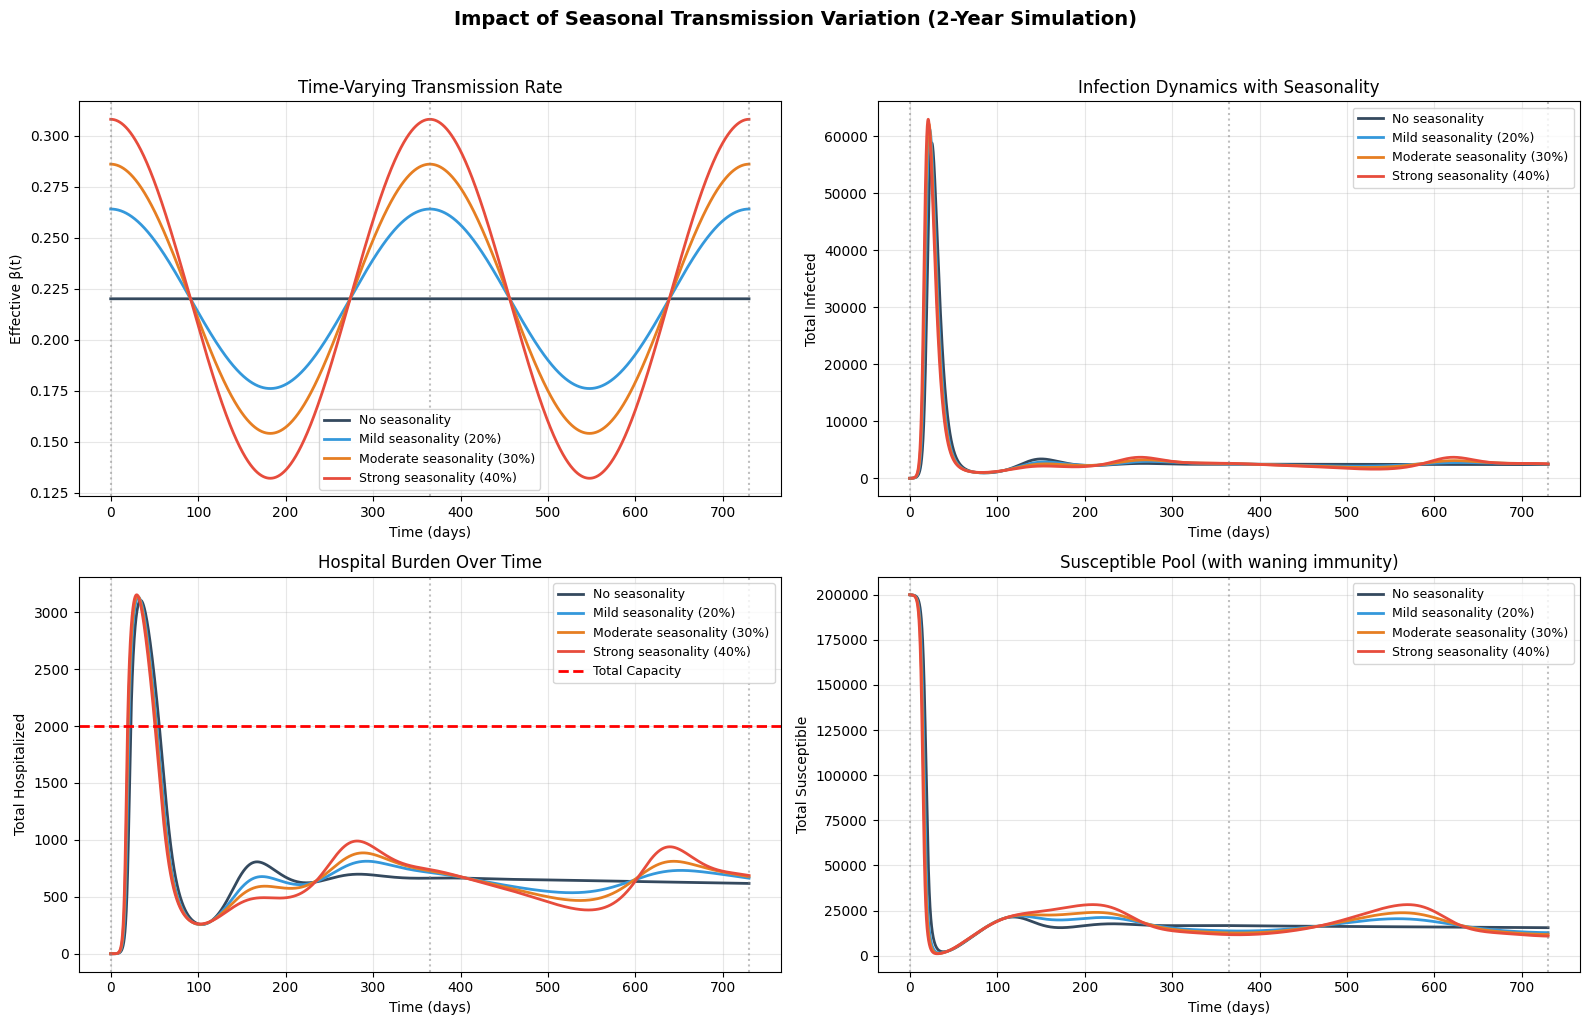

In [7]:
# Visualize seasonal effects
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colors = ['#34495e', '#3498db', '#e67e22', '#e74c3c']
times = seasonal_results['No seasonality']['times']

# Plot 1: Transmission rate β(t)
ax = axes[0, 0]
for i, (name, res) in enumerate(seasonal_results.items()):
    ax.plot(times, res['beta_t'], label=name, color=colors[i], linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Effective β(t)')
ax.set_title('Time-Varying Transmission Rate')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
# Add season markers
for year in range(3):
    ax.axvline(x=365*year, color='gray', linestyle=':', alpha=0.5)

# Plot 2: Infections over time
ax = axes[0, 1]
for i, (name, res) in enumerate(seasonal_results.items()):
    I_total = [sum(res['I'][a][t] for a in range(3)) for t in range(len(times))]
    ax.plot(times, I_total, label=name, color=colors[i], linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Total Infected')
ax.set_title('Infection Dynamics with Seasonality')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
for year in range(3):
    ax.axvline(x=365*year, color='gray', linestyle=':', alpha=0.5)

# Plot 3: Hospital burden
ax = axes[1, 0]
for i, (name, res) in enumerate(seasonal_results.items()):
    ax.plot(times, res['H_total'], label=name, color=colors[i], linewidth=2)
ax.axhline(y=ward_capacity + icu_capacity, color='red', linestyle='--', 
           label='Total Capacity', linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Total Hospitalized')
ax.set_title('Hospital Burden Over Time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
for year in range(3):
    ax.axvline(x=365*year, color='gray', linestyle=':', alpha=0.5)

# Plot 4: Susceptible population (shows waning + reinfection)
ax = axes[1, 1]
for i, (name, res) in enumerate(seasonal_results.items()):
    S_total = [sum(res['S'][a][t] for a in range(3)) for t in range(len(times))]
    ax.plot(times, S_total, label=name, color=colors[i], linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Total Susceptible')
ax.set_title('Susceptible Pool (with waning immunity)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
for year in range(3):
    ax.axvline(x=365*year, color='gray', linestyle=':', alpha=0.5)

plt.suptitle('Impact of Seasonal Transmission Variation (2-Year Simulation)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Experiment 4: Differential Mortality Analysis

Examine how capacity constraints lead to preventable deaths. This analysis highlights the importance of hospital capacity in epidemic response.

In [8]:
# ============================================
# Experiment 4: Differential Mortality Analysis
# ============================================

# Compare outcomes under different capacity scenarios
capacity_scenarios = {
    'Very limited (25%)': {'ward': ward_capacity * 0.25, 'icu': icu_capacity * 0.25},
    'Limited (50%)': {'ward': ward_capacity * 0.5, 'icu': icu_capacity * 0.5},
    'Standard (100%)': {'ward': ward_capacity, 'icu': icu_capacity},
    'Enhanced (150%)': {'ward': ward_capacity * 1.5, 'icu': icu_capacity * 1.5},
    'Surge (200%)': {'ward': ward_capacity * 2.0, 'icu': icu_capacity * 2.0},
}

capacity_results = {}
for name, caps in capacity_scenarios.items():
    capacity_results[name] = simulate_master_hospital_model(
        beta_base=0.28,  # Higher transmission to stress the system
        age_params=config.AGE_PARAMS_DEFAULT,
        contact_matrix=config.CONTACT_MATRIX_DEFAULT,
        ward_capacity=caps['ward'],
        icu_capacity=caps['icu'],
        coverage=[0.3, 0.4, 0.7],
        VE=0.7,
        age_pops=age_pops,
        Tmax=250,
        track_differential_mortality=True
    )

# Analyze differential mortality
print("="*90)
print("DIFFERENTIAL MORTALITY BY HOSPITAL CAPACITY")
print("="*90)
print(f"{'Scenario':<20} {'Ward Cap':>10} {'ICU Cap':>10} {'Treated':>12} {'Untreated':>12} {'% Preventable':>15}")
print("-"*90)

for name, res in capacity_results.items():
    caps = capacity_scenarios[name]
    treated = res['D_treated_total'][-1]
    untreated = res['D_untreated_total'][-1]
    total = treated + untreated
    pct_preventable = (untreated / total * 100) if total > 0 else 0
    print(f"{name:<20} {caps['ward']:>10.0f} {caps['icu']:>10.0f} {treated:>12.0f} {untreated:>12.0f} {pct_preventable:>14.1f}%")

DIFFERENTIAL MORTALITY BY HOSPITAL CAPACITY
Scenario               Ward Cap    ICU Cap      Treated    Untreated   % Preventable
------------------------------------------------------------------------------------------
Very limited (25%)          400        100         2362        15100           86.5%
Limited (50%)               800        200         3045        13630           81.7%
Standard (100%)            1600        400         4113        11403           73.5%
Enhanced (150%)            2400        600         4965         9679           66.1%
Surge (200%)               3200        800         5681         8272           59.3%


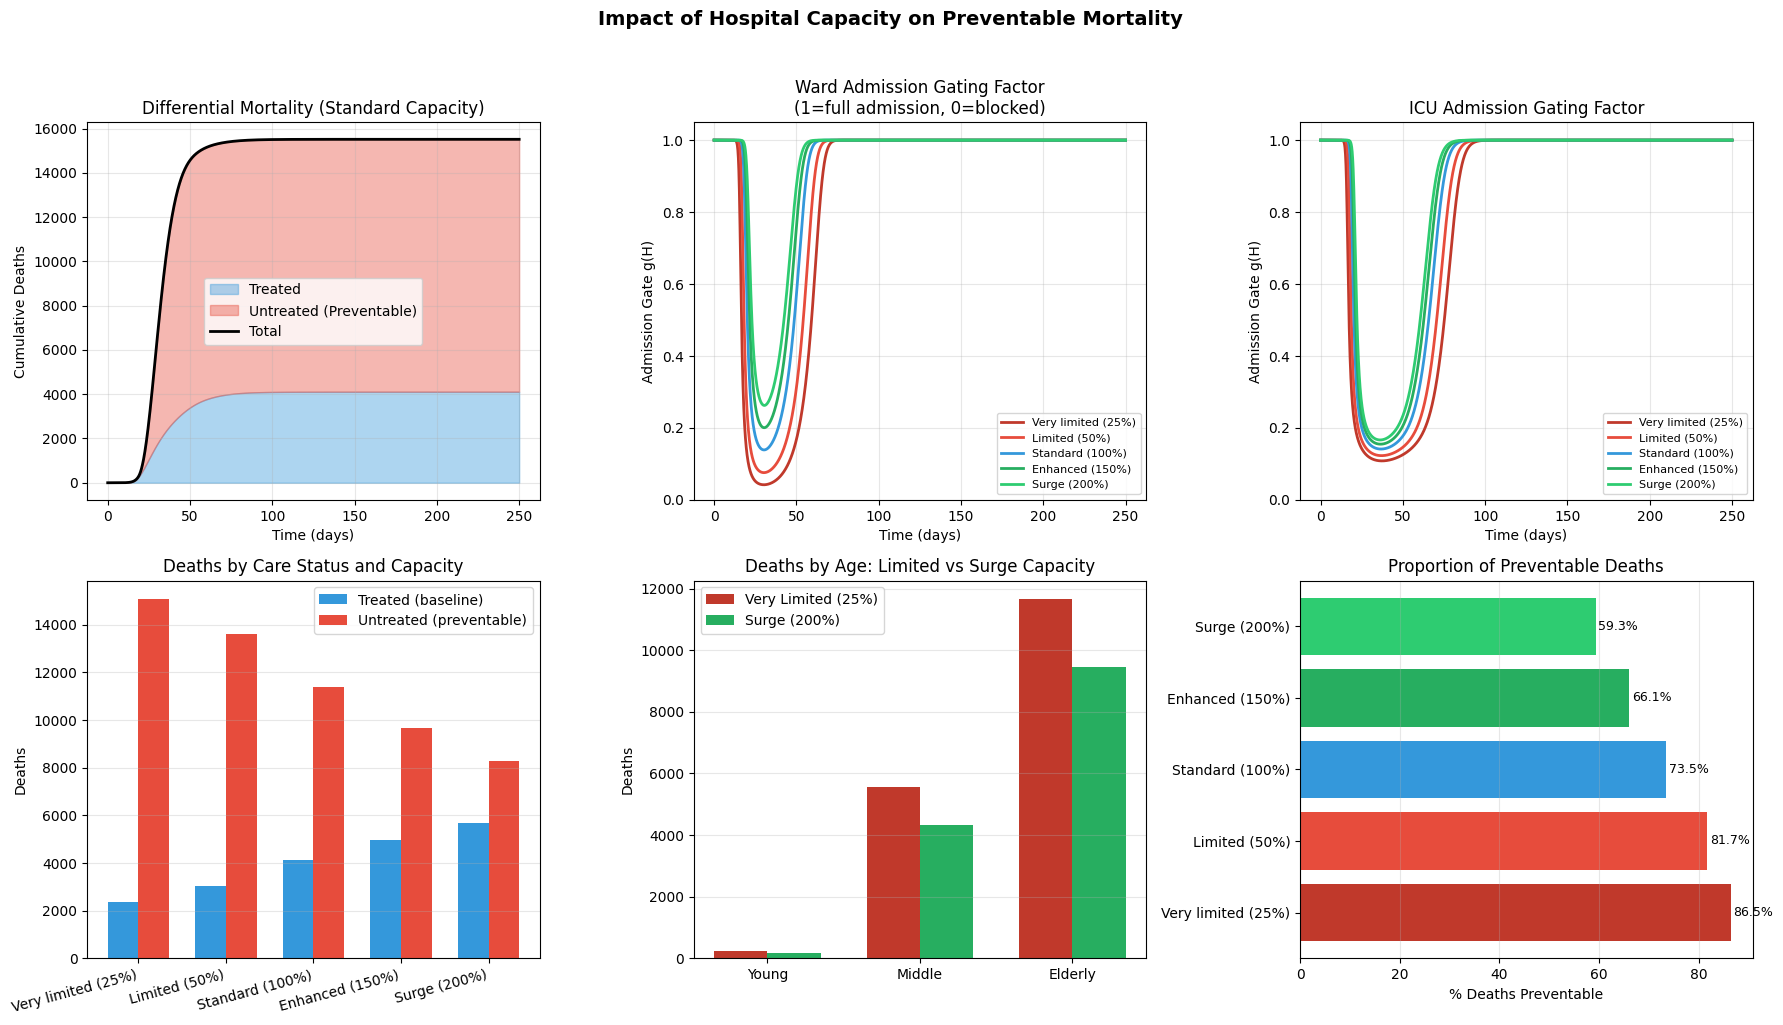

In [9]:
# Visualize differential mortality
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

colors = ['#c0392b', '#e74c3c', '#3498db', '#27ae60', '#2ecc71']
times = capacity_results['Standard (100%)']['times']

# Plot 1: Treated vs Untreated deaths over time (stacked)
ax = axes[0, 0]
for i, (name, res) in enumerate(capacity_results.items()):
    if i == 2:  # Highlight standard capacity
        ax.fill_between(times, 0, res['D_treated_total'], alpha=0.4, color='#3498db', label='Treated')
        ax.fill_between(times, res['D_treated_total'], 
                       np.array(res['D_treated_total']) + np.array(res['D_untreated_total']),
                       alpha=0.4, color='#e74c3c', label='Untreated (Preventable)')
        ax.plot(times, np.array(res['D_treated_total']) + np.array(res['D_untreated_total']),
               color='black', linewidth=2, label='Total')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Cumulative Deaths')
ax.set_title('Differential Mortality (Standard Capacity)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Ward admission gating factor
ax = axes[0, 1]
for i, (name, res) in enumerate(capacity_results.items()):
    ax.plot(times, res['g_ward'], label=name, color=colors[i], linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Admission Gate g(H)')
ax.set_title('Ward Admission Gating Factor\n(1=full admission, 0=blocked)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# Plot 3: ICU admission gating factor
ax = axes[0, 2]
for i, (name, res) in enumerate(capacity_results.items()):
    ax.plot(times, res['g_icu'], label=name, color=colors[i], linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Admission Gate g(H)')
ax.set_title('ICU Admission Gating Factor')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# Plot 4: Total deaths by capacity
ax = axes[1, 0]
scenario_names = list(capacity_results.keys())
treated = [capacity_results[n]['D_treated_total'][-1] for n in scenario_names]
untreated = [capacity_results[n]['D_untreated_total'][-1] for n in scenario_names]
x = np.arange(len(scenario_names))
width = 0.35
bars1 = ax.bar(x - width/2, treated, width, label='Treated (baseline)', color='#3498db')
bars2 = ax.bar(x + width/2, untreated, width, label='Untreated (preventable)', color='#e74c3c')
ax.set_ylabel('Deaths')
ax.set_title('Deaths by Care Status and Capacity')
ax.set_xticks(x)
ax.set_xticklabels(scenario_names, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 5: Deaths by age group under limited vs surge capacity
ax = axes[1, 1]
age_labels = config.AGE_LABELS_SHORT
limited_deaths = [capacity_results['Very limited (25%)']['D'][a][-1] for a in range(3)]
surge_deaths = [capacity_results['Surge (200%)']['D'][a][-1] for a in range(3)]
x = np.arange(3)
width = 0.35
ax.bar(x - width/2, limited_deaths, width, label='Very Limited (25%)', color='#c0392b')
ax.bar(x + width/2, surge_deaths, width, label='Surge (200%)', color='#27ae60')
ax.set_ylabel('Deaths')
ax.set_title('Deaths by Age: Limited vs Surge Capacity')
ax.set_xticks(x)
ax.set_xticklabels(age_labels)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 6: Preventable deaths percentage
ax = axes[1, 2]
pct_preventable = []
for name in scenario_names:
    res = capacity_results[name]
    total = res['D_treated_total'][-1] + res['D_untreated_total'][-1]
    pct = (res['D_untreated_total'][-1] / total * 100) if total > 0 else 0
    pct_preventable.append(pct)
bars = ax.barh(scenario_names, pct_preventable, color=colors)
ax.set_xlabel('% Deaths Preventable')
ax.set_title('Proportion of Preventable Deaths')
ax.grid(True, alpha=0.3, axis='x')
for bar, pct in zip(bars, pct_preventable):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{pct:.1f}%', va='center', fontsize=9)

plt.suptitle('Impact of Hospital Capacity on Preventable Mortality', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Experiment 5: Vaccination Strategy Comparison

Compare different age-targeted vaccination strategies to identify optimal allocation for minimizing deaths and hospital burden.

In [10]:
# ============================================
# Experiment 5: Vaccination Strategy Comparison
# ============================================

# Define vaccination strategies with same total coverage
vaccination_strategies = {
    'No vaccination': [0.0, 0.0, 0.0],
    'Uniform (40%)': [0.4, 0.4, 0.4],
    'Elderly priority': [0.1, 0.3, 0.8],      # Prioritize high-risk
    'Young priority': [0.8, 0.3, 0.1],        # Block transmission
    'Working-age focus': [0.2, 0.7, 0.3],     # Economic focus
    'High-risk first': [0.05, 0.25, 0.9],     # Maximum elderly protection
    'Transmission block': [0.6, 0.5, 0.2],    # Reduce spread
}

# Run all strategies
vax_results = {}
for name, coverage in vaccination_strategies.items():
    vax_results[name] = simulate_master_hospital_model(
        beta_base=0.28,
        age_params=config.AGE_PARAMS_DEFAULT,
        contact_matrix=config.CONTACT_MATRIX_DEFAULT,
        ward_capacity=ward_capacity,
        icu_capacity=icu_capacity,
        coverage=coverage,
        VE=0.7,
        age_pops=age_pops,
        Tmax=250,
        track_differential_mortality=True
    )

# Calculate total doses for each strategy
def calc_doses(coverage, age_pops):
    return sum(c * p for c, p in zip(coverage, age_pops))

print("="*100)
print("VACCINATION STRATEGY COMPARISON")
print("="*100)
print(f"{'Strategy':<22} {'Coverage (Y/M/E)':>18} {'Doses':>12} {'Deaths':>10} {'Peak Ward':>12} {'Peak ICU':>10}")
print("-"*100)

for name in vaccination_strategies:
    cov = vaccination_strategies[name]
    res = vax_results[name]
    doses = calc_doses(cov, age_pops)
    deaths = sum(res['D'][a][-1] for a in range(3))
    peak_w = max(res['H_ward_total'])
    peak_i = max(res['H_icu_total'])
    cov_str = f"{cov[0]:.0%}/{cov[1]:.0%}/{cov[2]:.0%}"
    print(f"{name:<22} {cov_str:>18} {doses:>12,.0f} {deaths:>10.0f} {peak_w:>12.0f} {peak_i:>10.0f}")

VACCINATION STRATEGY COMPARISON
Strategy                 Coverage (Y/M/E)        Doses     Deaths    Peak Ward   Peak ICU
----------------------------------------------------------------------------------------------------
No vaccination                   0%/0%/0%            0      15649         2576        633
Uniform (40%)                 40%/40%/40%       80,000      15583         2552        631
Elderly priority              10%/30%/80%       68,000      15461         2509        626
Young priority                80%/30%/10%       82,000      15577         2560        634
Working-age focus             20%/70%/30%       94,000      15566         2554        634
High-risk first                5%/25%/90%       64,000      15332         2485        624
Transmission block            60%/50%/20%       94,000      15568         2557        634


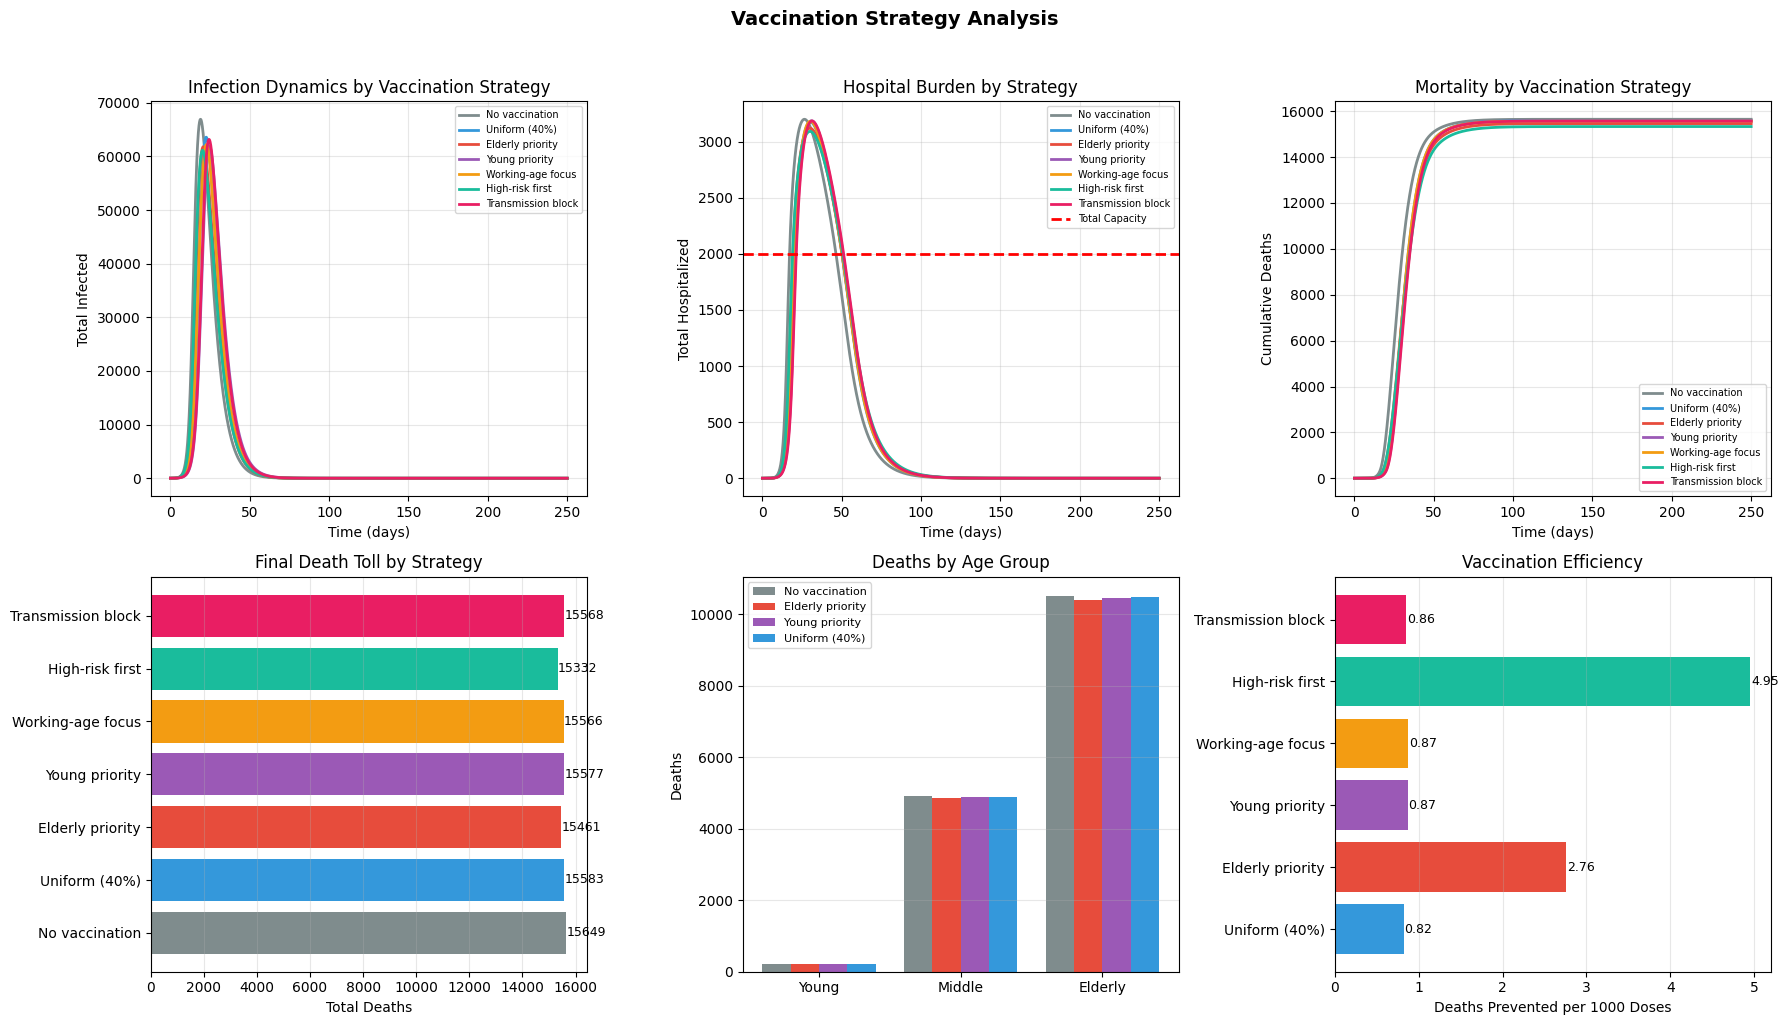

In [11]:
# Visualize vaccination strategy comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

strategy_colors = ['#7f8c8d', '#3498db', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#e91e63']
times = vax_results['No vaccination']['times']
strategy_names = list(vaccination_strategies.keys())

# Plot 1: Infection curves
ax = axes[0, 0]
for i, name in enumerate(strategy_names):
    res = vax_results[name]
    I_total = [sum(res['I'][a][t] for a in range(3)) for t in range(len(times))]
    ax.plot(times, I_total, label=name, color=strategy_colors[i], linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Total Infected')
ax.set_title('Infection Dynamics by Vaccination Strategy')
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3)

# Plot 2: Hospital burden
ax = axes[0, 1]
for i, name in enumerate(strategy_names):
    res = vax_results[name]
    ax.plot(times, res['H_total'], label=name, color=strategy_colors[i], linewidth=2)
ax.axhline(y=ward_capacity + icu_capacity, color='red', linestyle='--', 
           label='Total Capacity', linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Total Hospitalized')
ax.set_title('Hospital Burden by Strategy')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Plot 3: Cumulative deaths
ax = axes[0, 2]
for i, name in enumerate(strategy_names):
    res = vax_results[name]
    D_total = [sum(res['D'][a][t] for a in range(3)) for t in range(len(times))]
    ax.plot(times, D_total, label=name, color=strategy_colors[i], linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Cumulative Deaths')
ax.set_title('Mortality by Vaccination Strategy')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Plot 4: Deaths comparison bar chart
ax = axes[1, 0]
deaths = [sum(vax_results[n]['D'][a][-1] for a in range(3)) for n in strategy_names]
bars = ax.barh(strategy_names, deaths, color=strategy_colors)
ax.set_xlabel('Total Deaths')
ax.set_title('Final Death Toll by Strategy')
ax.grid(True, alpha=0.3, axis='x')
for bar, d in zip(bars, deaths):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
            f'{d:.0f}', va='center', fontsize=9)

# Plot 5: Deaths by age group for selected strategies
ax = axes[1, 1]
selected = ['No vaccination', 'Elderly priority', 'Young priority', 'Uniform (40%)']
x = np.arange(3)
width = 0.2
for i, name in enumerate(selected):
    age_deaths = [vax_results[name]['D'][a][-1] for a in range(3)]
    ax.bar(x + i*width, age_deaths, width, label=name, 
           color=strategy_colors[strategy_names.index(name)])
ax.set_ylabel('Deaths')
ax.set_title('Deaths by Age Group')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(config.AGE_LABELS_SHORT)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Plot 6: Efficiency (deaths prevented per 1000 doses)
ax = axes[1, 2]
baseline_deaths = sum(vax_results['No vaccination']['D'][a][-1] for a in range(3))
efficiency = []
names_for_eff = []
for name in strategy_names:
    if name == 'No vaccination':
        continue
    cov = vaccination_strategies[name]
    doses = calc_doses(cov, age_pops)
    deaths = sum(vax_results[name]['D'][a][-1] for a in range(3))
    prevented = baseline_deaths - deaths
    eff = (prevented / doses) * 1000 if doses > 0 else 0
    efficiency.append(eff)
    names_for_eff.append(name)

bars = ax.barh(names_for_eff, efficiency, color=strategy_colors[1:])
ax.set_xlabel('Deaths Prevented per 1000 Doses')
ax.set_title('Vaccination Efficiency')
ax.grid(True, alpha=0.3, axis='x')
for bar, e in zip(bars, efficiency):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{e:.2f}', va='center', fontsize=9)

plt.suptitle('Vaccination Strategy Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Experiment 6: Waning Immunity and Endemic Dynamics

Explore how different rates of waning immunity affect long-term epidemic dynamics and the potential for endemic equilibrium.

In [12]:
# ============================================
# Experiment 6: Waning Immunity Analysis
# ============================================

# Different waning immunity scenarios
waning_scenarios = {
    'No waning (permanent immunity)': {'omega': 0.0},
    'Slow waning (~3 years)': {'omega': 0.001},
    'Moderate waning (~1 year)': {'omega': 0.003},
    'Fast waning (~6 months)': {'omega': 0.006},
    'Very fast (~3 months)': {'omega': 0.011},
    'Age-specific waning': {
        'omega_young': 0.001,   # Young maintain immunity longer
        'omega_middle': 0.003,
        'omega_elderly': 0.008  # Elderly lose immunity faster
    }
}

# Run 3-year simulations
waning_results = {}
for name, params in waning_scenarios.items():
    waning_results[name] = simulate_master_hospital_model(
        beta_base=0.20,  # Lower transmission to see long-term dynamics
        age_params=config.AGE_PARAMS_DEFAULT,
        contact_matrix=config.CONTACT_MATRIX_DEFAULT,
        ward_capacity=ward_capacity,
        icu_capacity=icu_capacity,
        coverage=[0.3, 0.4, 0.7],
        VE=0.7,
        age_pops=age_pops,
        waning_params=params,
        seasonal_params={'amplitude': 0.2, 'period': 365, 'peak_day': 180},
        Tmax=1095,  # 3 years
        track_differential_mortality=True
    )

print("="*80)
print("WANING IMMUNITY COMPARISON (3-year simulation)")
print("="*80)
print(f"{'Scenario':<35} {'Total Deaths':>15} {'Final Year Deaths':>18}")
print("-"*80)

for name, res in waning_results.items():
    total_deaths = sum(res['D'][a][-1] for a in range(3))
    # Deaths in final year (day 730 to 1095)
    idx_730 = int(730 / 0.1)  # Find index for day 730
    deaths_yr3 = total_deaths - sum(res['D'][a][idx_730] for a in range(3))
    print(f"{name:<35} {total_deaths:>15.0f} {deaths_yr3:>18.0f}")

WANING IMMUNITY COMPARISON (3-year simulation)
Scenario                               Total Deaths  Final Year Deaths
--------------------------------------------------------------------------------
No waning (permanent immunity)                14991                  0
Slow waning (~3 years)                        21561               2696
Moderate waning (~1 year)                     34302               6567
Fast waning (~6 months)                       48343              10042
Very fast (~3 months)                         65686              12898
Age-specific waning                           42212               7896


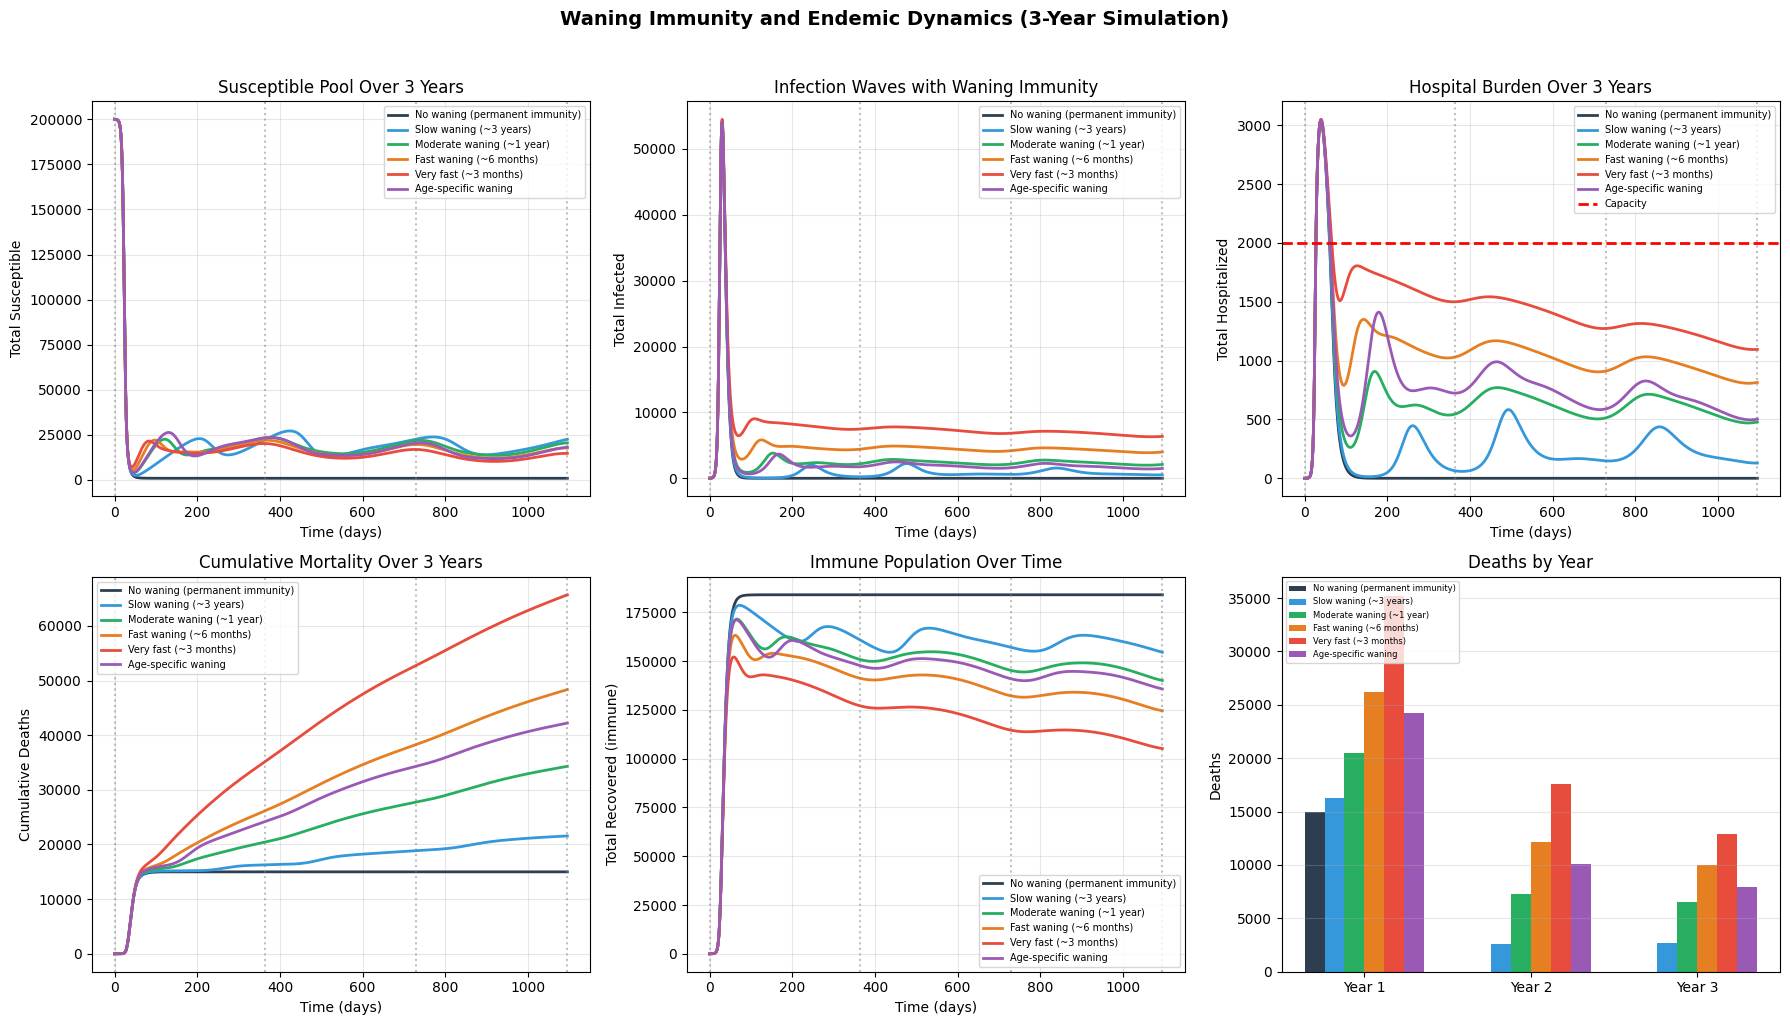

In [13]:
# Visualize waning immunity effects
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

colors = ['#2c3e50', '#3498db', '#27ae60', '#e67e22', '#e74c3c', '#9b59b6']
scenario_names = list(waning_scenarios.keys())

# Plot 1: Susceptible population over time
ax = axes[0, 0]
for i, name in enumerate(scenario_names):
    res = waning_results[name]
    times = res['times']
    S_total = [sum(res['S'][a][t] for a in range(3)) for t in range(len(times))]
    ax.plot(times, S_total, label=name, color=colors[i], linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Total Susceptible')
ax.set_title('Susceptible Pool Over 3 Years')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
# Add year markers
for year in range(4):
    ax.axvline(x=365*year, color='gray', linestyle=':', alpha=0.5)

# Plot 2: Infection dynamics
ax = axes[0, 1]
for i, name in enumerate(scenario_names):
    res = waning_results[name]
    times = res['times']
    I_total = [sum(res['I'][a][t] for a in range(3)) for t in range(len(times))]
    ax.plot(times, I_total, label=name, color=colors[i], linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Total Infected')
ax.set_title('Infection Waves with Waning Immunity')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
for year in range(4):
    ax.axvline(x=365*year, color='gray', linestyle=':', alpha=0.5)

# Plot 3: Hospital burden
ax = axes[0, 2]
for i, name in enumerate(scenario_names):
    res = waning_results[name]
    times = res['times']
    ax.plot(times, res['H_total'], label=name, color=colors[i], linewidth=2)
ax.axhline(y=ward_capacity + icu_capacity, color='red', linestyle='--', 
           label='Capacity', linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Total Hospitalized')
ax.set_title('Hospital Burden Over 3 Years')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
for year in range(4):
    ax.axvline(x=365*year, color='gray', linestyle=':', alpha=0.5)

# Plot 4: Cumulative deaths
ax = axes[1, 0]
for i, name in enumerate(scenario_names):
    res = waning_results[name]
    times = res['times']
    D_total = [sum(res['D'][a][t] for a in range(3)) for t in range(len(times))]
    ax.plot(times, D_total, label=name, color=colors[i], linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Cumulative Deaths')
ax.set_title('Cumulative Mortality Over 3 Years')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
for year in range(4):
    ax.axvline(x=365*year, color='gray', linestyle=':', alpha=0.5)

# Plot 5: Recovered population
ax = axes[1, 1]
for i, name in enumerate(scenario_names):
    res = waning_results[name]
    times = res['times']
    R_total = [sum(res['R'][a][t] for a in range(3)) for t in range(len(times))]
    ax.plot(times, R_total, label=name, color=colors[i], linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Total Recovered (immune)')
ax.set_title('Immune Population Over Time')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
for year in range(4):
    ax.axvline(x=365*year, color='gray', linestyle=':', alpha=0.5)

# Plot 6: Deaths by year
ax = axes[1, 2]
year_deaths = {name: [] for name in scenario_names}
for name in scenario_names:
    res = waning_results[name]
    times = res['times']
    D_total = [sum(res['D'][a][t] for a in range(3)) for t in range(len(times))]
    for year in range(3):
        idx_start = int(365 * year / 0.1)
        idx_end = int(365 * (year + 1) / 0.1)
        if idx_end < len(D_total):
            year_deaths[name].append(D_total[idx_end] - D_total[idx_start])
        else:
            year_deaths[name].append(D_total[-1] - D_total[idx_start])

x = np.arange(3)
width = 0.12
for i, name in enumerate(scenario_names):
    ax.bar(x + i*width, year_deaths[name], width, label=name, color=colors[i])
ax.set_ylabel('Deaths')
ax.set_title('Deaths by Year')
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(['Year 1', 'Year 2', 'Year 3'])
ax.legend(fontsize=6, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Waning Immunity and Endemic Dynamics (3-Year Simulation)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Experiment 7: Combined Scenario - Realistic Pandemic Response

Simulate a realistic pandemic scenario combining all model features: seasonal transmission, policy interventions, vaccination rollout, and waning immunity.

In [14]:
# ============================================
# Experiment 7: Realistic Pandemic Response
# ============================================

# Define comprehensive intervention timeline
realistic_interventions = [
    # Initial surge lockdown
    {'start_day': 30, 'end_day': 75, 'transmission_reduction': 0.5},
    # Summer relaxation followed by fall restrictions
    {'start_day': 150, 'end_day': 200, 'transmission_reduction': 0.3},
    # Winter surge response (year 2)
    {'start_day': 400, 'end_day': 450, 'transmission_reduction': 0.4},
]

# Run comprehensive simulation
comprehensive_results = simulate_master_hospital_model(
    beta_base=0.25,
    age_params=config.AGE_PARAMS_DEFAULT,
    contact_matrix=config.CONTACT_MATRIX_DEFAULT,
    ward_capacity=ward_capacity,
    icu_capacity=icu_capacity,
    coverage=[0.3, 0.5, 0.8],  # Realistic age-targeted coverage
    VE=0.7,
    age_pops=age_pops,
    seasonal_params={
        'amplitude': 0.25,
        'period': 365,
        'peak_day': 0  # Winter peak
    },
    waning_params={
        'omega_young': 0.002,
        'omega_middle': 0.003,
        'omega_elderly': 0.005
    },
    interventions=realistic_interventions,
    Tmax=730,  # 2 years
    track_differential_mortality=True,
    track_compartment_flows=True
)

# Print comprehensive summary
times = comprehensive_results['times']
total_pop = sum(age_pops)
final_deaths = sum(comprehensive_results['D'][a][-1] for a in range(3))
final_recovered = sum(comprehensive_results['R'][a][-1] for a in range(3))
final_susceptible = sum(comprehensive_results['S'][a][-1] for a in range(3))
total_infected = total_pop - final_susceptible

print("="*70)
print("COMPREHENSIVE PANDEMIC SIMULATION (2-Year)")
print("="*70)
print("\n📊 POPULATION SUMMARY")
print(f"  Total population: {total_pop:,}")
print(f"  Total infected: {total_infected:,.0f} ({total_infected/total_pop*100:.1f}%)")
print(f"  Final immune: {final_recovered:,.0f}")
print(f"  Remaining susceptible: {final_susceptible:,.0f}")

print("\n💀 MORTALITY")
print(f"  Total deaths: {final_deaths:,.0f}")
print(f"  Infection Fatality Rate: {final_deaths/total_infected*100:.2f}%")
print(f"  Treated deaths: {comprehensive_results['D_treated_total'][-1]:,.0f}")
print(f"  Preventable deaths: {comprehensive_results['D_untreated_total'][-1]:,.0f}")

print("\n🏥 HOSPITAL METRICS")
print(f"  Peak ward: {max(comprehensive_results['H_ward_total']):,.0f} / {ward_capacity}")
print(f"  Peak ICU: {max(comprehensive_results['H_icu_total']):,.0f} / {icu_capacity}")
print(f"  Cum. ward overflow: {comprehensive_results['cum_ward_overflow']:,.0f} patient-days")
print(f"  Cum. ICU overflow: {comprehensive_results['cum_icu_overflow']:,.0f} patient-days")

print("\n📈 BY AGE GROUP")
for a, label in enumerate(config.AGE_LABELS_SHORT):
    deaths_a = comprehensive_results['D'][a][-1]
    pop_a = age_pops[a]
    infected_a = pop_a - comprehensive_results['S'][a][-1]
    ifr_a = (deaths_a / infected_a * 100) if infected_a > 0 else 0
    print(f"  {label}: {deaths_a:,.0f} deaths (IFR: {ifr_a:.2f}%)")

COMPREHENSIVE PANDEMIC SIMULATION (2-Year)

📊 POPULATION SUMMARY
  Total population: 200,000
  Total infected: 188,241 (94.1%)
  Final immune: 150,987
  Remaining susceptible: 11,759

💀 MORTALITY
  Total deaths: 31,613
  Infection Fatality Rate: 16.79%
  Treated deaths: 18,537
  Preventable deaths: 13,076

🏥 HOSPITAL METRICS
  Peak ward: 2,523 / 1600
  Peak ICU: 628 / 400
  Cum. ward overflow: 17,677 patient-days
  Cum. ICU overflow: 11,406 patient-days

📈 BY AGE GROUP
  Young: 342 deaths (IFR: 0.59%)
  Middle: 10,281 deaths (IFR: 10.89%)
  Elderly: 20,990 deaths (IFR: 58.12%)


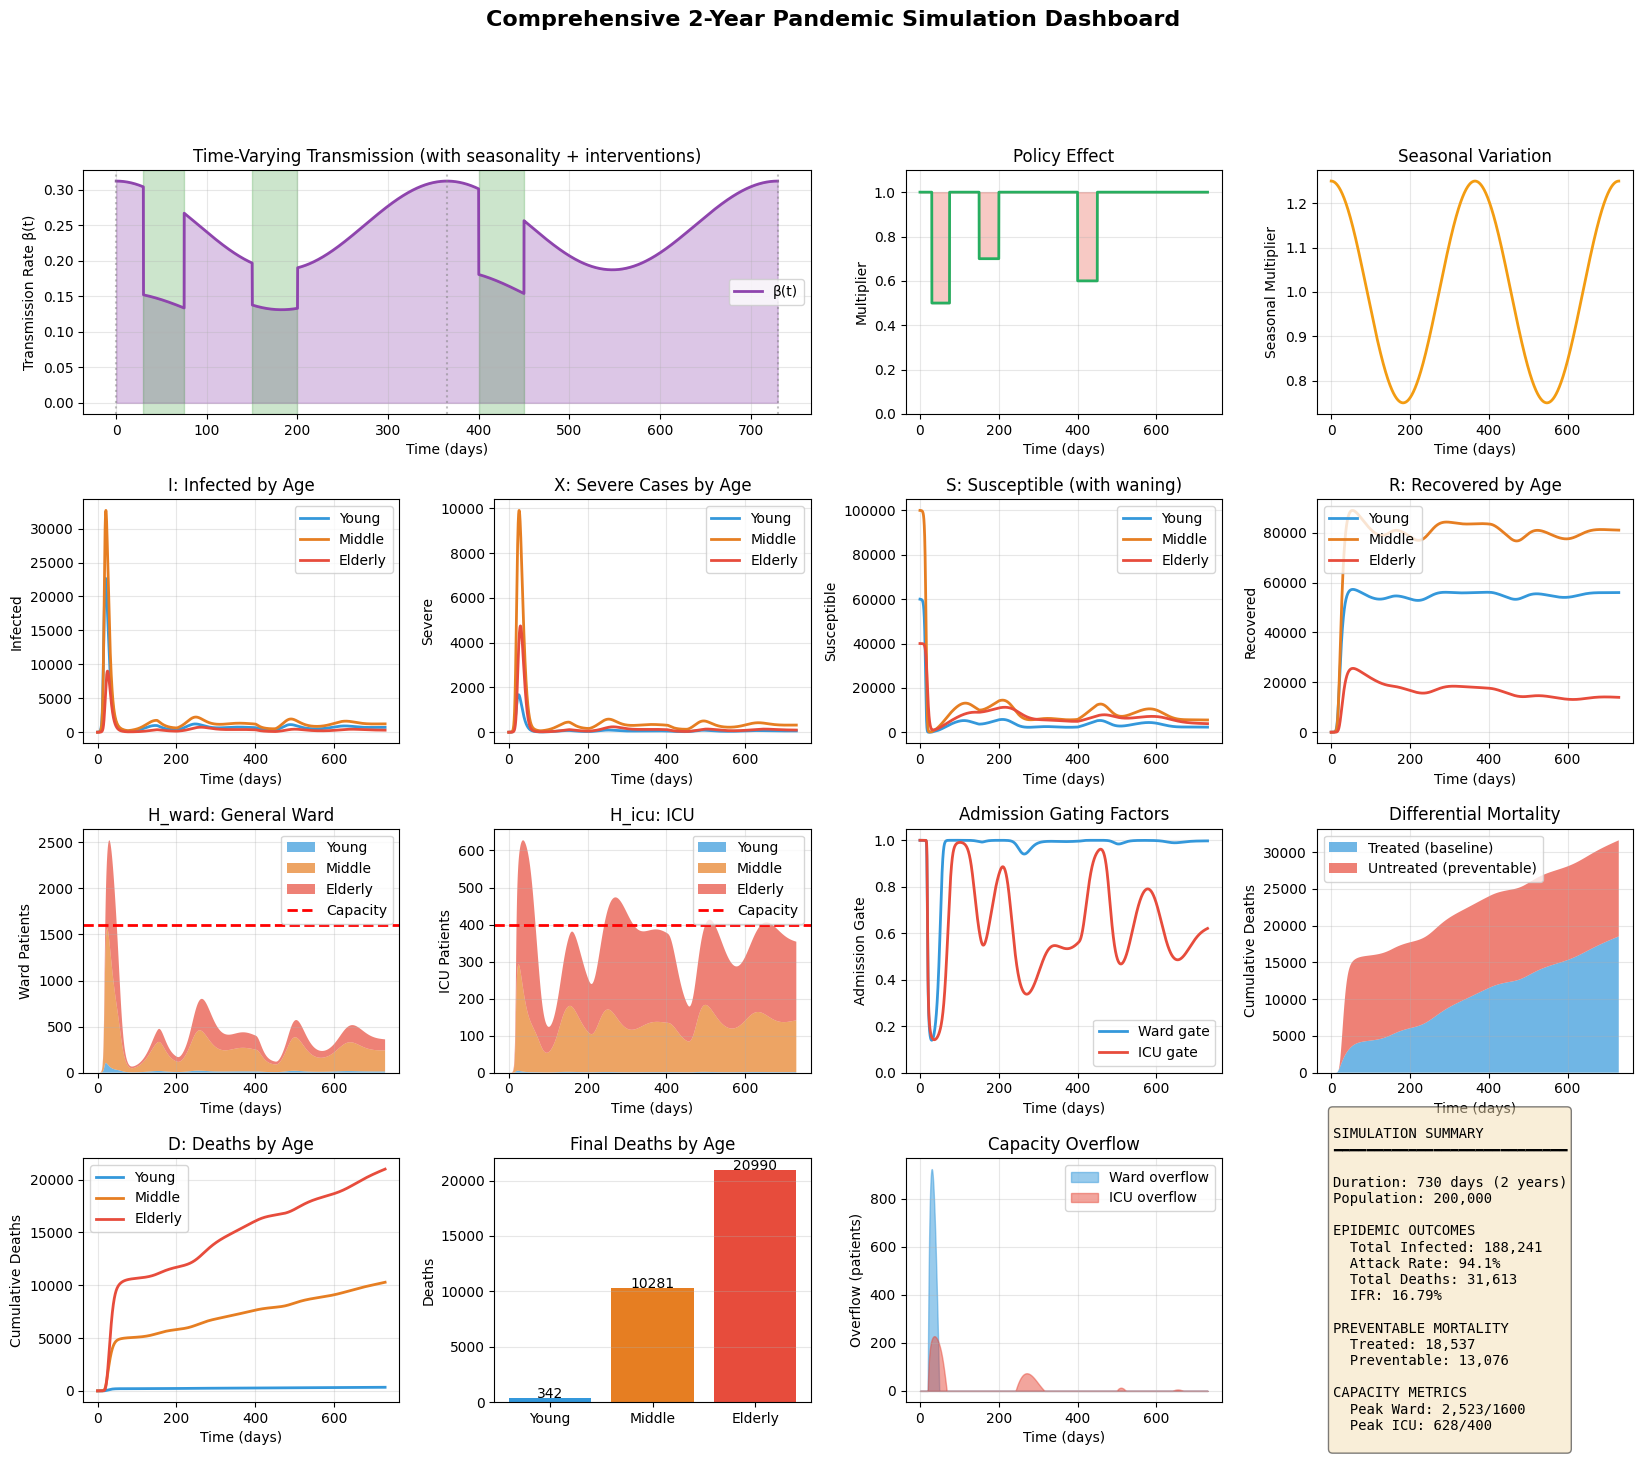

In [15]:
# Create comprehensive dashboard visualization
fig = plt.figure(figsize=(20, 16))
gs = GridSpec(4, 4, figure=fig, hspace=0.35, wspace=0.3)

times = comprehensive_results['times']
age_colors = ['#3498db', '#e67e22', '#e74c3c']

# ========================================
# Row 1: Time-varying parameters and transmission
# ========================================

# Plot 1: Transmission rate with interventions
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.plot(times, comprehensive_results['beta_t'], color='#8e44ad', linewidth=2, label='β(t)')
ax1.fill_between(times, 0, comprehensive_results['beta_t'], alpha=0.3, color='#8e44ad')
# Shade intervention periods
for intervention in realistic_interventions:
    ax1.axvspan(intervention['start_day'], intervention['end_day'], 
                alpha=0.2, color='green', label='_nolegend_')
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Transmission Rate β(t)')
ax1.set_title('Time-Varying Transmission (with seasonality + interventions)')
ax1.legend()
ax1.grid(True, alpha=0.3)
# Year markers
for year in range(3):
    ax1.axvline(x=365*year, color='gray', linestyle=':', alpha=0.5)

# Plot 2: Policy multiplier
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(times, comprehensive_results['policy_mult'], color='#27ae60', linewidth=2)
ax2.fill_between(times, comprehensive_results['policy_mult'], 1, alpha=0.3, color='#e74c3c')
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Multiplier')
ax2.set_title('Policy Effect')
ax2.set_ylim([0, 1.1])
ax2.grid(True, alpha=0.3)

# Plot 3: Seasonal factor
ax3 = fig.add_subplot(gs[0, 3])
ax3.plot(times, comprehensive_results['seasonal_factor'], color='#f39c12', linewidth=2)
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('Seasonal Multiplier')
ax3.set_title('Seasonal Variation')
ax3.grid(True, alpha=0.3)

# ========================================
# Row 2: Epidemic compartments
# ========================================

# Plot 4: Infections by age
ax4 = fig.add_subplot(gs[1, 0])
for a in range(3):
    ax4.plot(times, comprehensive_results['I'][a], color=age_colors[a], 
             linewidth=2, label=config.AGE_LABELS_SHORT[a])
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('Infected')
ax4.set_title('I: Infected by Age')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: Severe cases by age
ax5 = fig.add_subplot(gs[1, 1])
for a in range(3):
    ax5.plot(times, comprehensive_results['X'][a], color=age_colors[a], 
             linewidth=2, label=config.AGE_LABELS_SHORT[a])
ax5.set_xlabel('Time (days)')
ax5.set_ylabel('Severe')
ax5.set_title('X: Severe Cases by Age')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: Susceptibles (showing waning)
ax6 = fig.add_subplot(gs[1, 2])
for a in range(3):
    ax6.plot(times, comprehensive_results['S'][a], color=age_colors[a], 
             linewidth=2, label=config.AGE_LABELS_SHORT[a])
ax6.set_xlabel('Time (days)')
ax6.set_ylabel('Susceptible')
ax6.set_title('S: Susceptible (with waning)')
ax6.legend()
ax6.grid(True, alpha=0.3)

# Plot 7: Recovered
ax7 = fig.add_subplot(gs[1, 3])
for a in range(3):
    ax7.plot(times, comprehensive_results['R'][a], color=age_colors[a], 
             linewidth=2, label=config.AGE_LABELS_SHORT[a])
ax7.set_xlabel('Time (days)')
ax7.set_ylabel('Recovered')
ax7.set_title('R: Recovered by Age')
ax7.legend()
ax7.grid(True, alpha=0.3)

# ========================================
# Row 3: Hospital dynamics
# ========================================

# Plot 8: Ward occupancy
ax8 = fig.add_subplot(gs[2, 0])
ax8.stackplot(times, 
              [comprehensive_results['H_ward'][a] for a in range(3)],
              labels=config.AGE_LABELS_SHORT, colors=age_colors, alpha=0.7)
ax8.axhline(y=ward_capacity, color='red', linestyle='--', linewidth=2, label='Capacity')
ax8.set_xlabel('Time (days)')
ax8.set_ylabel('Ward Patients')
ax8.set_title('H_ward: General Ward')
ax8.legend(loc='upper right')
ax8.grid(True, alpha=0.3)

# Plot 9: ICU occupancy
ax9 = fig.add_subplot(gs[2, 1])
ax9.stackplot(times, 
              [comprehensive_results['H_icu'][a] for a in range(3)],
              labels=config.AGE_LABELS_SHORT, colors=age_colors, alpha=0.7)
ax9.axhline(y=icu_capacity, color='red', linestyle='--', linewidth=2, label='Capacity')
ax9.set_xlabel('Time (days)')
ax9.set_ylabel('ICU Patients')
ax9.set_title('H_icu: ICU')
ax9.legend(loc='upper right')
ax9.grid(True, alpha=0.3)

# Plot 10: Gating factors
ax10 = fig.add_subplot(gs[2, 2])
ax10.plot(times, comprehensive_results['g_ward'], color='#3498db', 
          linewidth=2, label='Ward gate')
ax10.plot(times, comprehensive_results['g_icu'], color='#e74c3c', 
          linewidth=2, label='ICU gate')
ax10.set_xlabel('Time (days)')
ax10.set_ylabel('Admission Gate')
ax10.set_title('Admission Gating Factors')
ax10.set_ylim([0, 1.05])
ax10.legend()
ax10.grid(True, alpha=0.3)

# Plot 11: Differential mortality
ax11 = fig.add_subplot(gs[2, 3])
ax11.stackplot(times,
               comprehensive_results['D_treated_total'],
               comprehensive_results['D_untreated_total'],
               labels=['Treated (baseline)', 'Untreated (preventable)'],
               colors=['#3498db', '#e74c3c'], alpha=0.7)
ax11.set_xlabel('Time (days)')
ax11.set_ylabel('Cumulative Deaths')
ax11.set_title('Differential Mortality')
ax11.legend(loc='upper left')
ax11.grid(True, alpha=0.3)

# ========================================
# Row 4: Summary metrics
# ========================================

# Plot 12: Deaths by age
ax12 = fig.add_subplot(gs[3, 0])
for a in range(3):
    ax12.plot(times, comprehensive_results['D'][a], color=age_colors[a], 
              linewidth=2, label=config.AGE_LABELS_SHORT[a])
ax12.set_xlabel('Time (days)')
ax12.set_ylabel('Cumulative Deaths')
ax12.set_title('D: Deaths by Age')
ax12.legend()
ax12.grid(True, alpha=0.3)

# Plot 13: Final deaths breakdown (bar)
ax13 = fig.add_subplot(gs[3, 1])
deaths_by_age = [comprehensive_results['D'][a][-1] for a in range(3)]
bars = ax13.bar(config.AGE_LABELS_SHORT, deaths_by_age, color=age_colors)
ax13.set_ylabel('Deaths')
ax13.set_title('Final Deaths by Age')
for bar, d in zip(bars, deaths_by_age):
    ax13.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
              f'{d:.0f}', ha='center', fontsize=10)
ax13.grid(True, alpha=0.3, axis='y')

# Plot 14: Hospital overflow
ax14 = fig.add_subplot(gs[3, 2])
ax14.fill_between(times, 0, comprehensive_results['ward_overflow'], 
                  alpha=0.5, color='#3498db', label='Ward overflow')
ax14.fill_between(times, 0, comprehensive_results['icu_overflow'], 
                  alpha=0.5, color='#e74c3c', label='ICU overflow')
ax14.set_xlabel('Time (days)')
ax14.set_ylabel('Overflow (patients)')
ax14.set_title('Capacity Overflow')
ax14.legend()
ax14.grid(True, alpha=0.3)

# Plot 15: Summary text panel
ax15 = fig.add_subplot(gs[3, 3])
ax15.axis('off')
summary_text = f"""
SIMULATION SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Duration: 730 days (2 years)
Population: {sum(age_pops):,}

EPIDEMIC OUTCOMES
  Total Infected: {total_infected:,.0f}
  Attack Rate: {total_infected/total_pop*100:.1f}%
  Total Deaths: {final_deaths:,.0f}
  IFR: {final_deaths/total_infected*100:.2f}%

PREVENTABLE MORTALITY
  Treated: {comprehensive_results['D_treated_total'][-1]:,.0f}
  Preventable: {comprehensive_results['D_untreated_total'][-1]:,.0f}

CAPACITY METRICS
  Peak Ward: {max(comprehensive_results['H_ward_total']):,.0f}/{ward_capacity}
  Peak ICU: {max(comprehensive_results['H_icu_total']):,.0f}/{icu_capacity}
"""
ax15.text(0.05, 0.5, summary_text, fontsize=10, family='monospace',
          verticalalignment='center', transform=ax15.transAxes,
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Comprehensive 2-Year Pandemic Simulation Dashboard', 
             fontsize=16, fontweight='bold', y=0.98)
plt.show()

# Experiment 8: Sensitivity Analysis

Explore how key parameters affect outcomes to understand model sensitivity and identify critical intervention points.

In [16]:
# ============================================
# Experiment 8: Parameter Sensitivity Analysis
# ============================================

# Analyze sensitivity to transmission rate (beta)
beta_values = np.linspace(0.15, 0.35, 9)
beta_sensitivity = {'beta': [], 'deaths': [], 'peak_ward': [], 'peak_icu': [], 'attack_rate': []}

for beta in beta_values:
    res = simulate_master_hospital_model(
        beta_base=beta,
        age_params=config.AGE_PARAMS_DEFAULT,
        contact_matrix=config.CONTACT_MATRIX_DEFAULT,
        ward_capacity=ward_capacity,
        icu_capacity=icu_capacity,
        coverage=[0.3, 0.4, 0.7],
        VE=0.7,
        age_pops=age_pops,
        Tmax=200
    )
    total_deaths = sum(res['D'][a][-1] for a in range(3))
    S_final = sum(res['S'][a][-1] for a in range(3))
    attack_rate = (sum(age_pops) - S_final) / sum(age_pops) * 100
    
    beta_sensitivity['beta'].append(beta)
    beta_sensitivity['deaths'].append(total_deaths)
    beta_sensitivity['peak_ward'].append(max(res['H_ward_total']))
    beta_sensitivity['peak_icu'].append(max(res['H_icu_total']))
    beta_sensitivity['attack_rate'].append(attack_rate)

# Analyze sensitivity to vaccine efficacy
ve_values = np.linspace(0.3, 0.95, 9)
ve_sensitivity = {'VE': [], 'deaths': [], 'peak_ward': [], 'prevented': []}
baseline_deaths = beta_sensitivity['deaths'][4]  # Deaths at beta=0.25

for ve in ve_values:
    res = simulate_master_hospital_model(
        beta_base=0.25,
        age_params=config.AGE_PARAMS_DEFAULT,
        contact_matrix=config.CONTACT_MATRIX_DEFAULT,
        ward_capacity=ward_capacity,
        icu_capacity=icu_capacity,
        coverage=[0.3, 0.4, 0.7],
        VE=ve,
        age_pops=age_pops,
        Tmax=200
    )
    total_deaths = sum(res['D'][a][-1] for a in range(3))
    
    ve_sensitivity['VE'].append(ve)
    ve_sensitivity['deaths'].append(total_deaths)
    ve_sensitivity['peak_ward'].append(max(res['H_ward_total']))
    ve_sensitivity['prevented'].append(baseline_deaths - total_deaths)

print("="*60)
print("SENSITIVITY ANALYSIS RESULTS")
print("="*60)
print("\nTransmission Rate (β) Sensitivity:")
print(f"  β range: {min(beta_values):.2f} - {max(beta_values):.2f}")
print(f"  Deaths range: {min(beta_sensitivity['deaths']):.0f} - {max(beta_sensitivity['deaths']):.0f}")
print(f"  Peak ward range: {min(beta_sensitivity['peak_ward']):.0f} - {max(beta_sensitivity['peak_ward']):.0f}")

print("\nVaccine Efficacy Sensitivity:")
print(f"  VE range: {min(ve_values):.0%} - {max(ve_values):.0%}")
print(f"  Deaths range: {min(ve_sensitivity['deaths']):.0f} - {max(ve_sensitivity['deaths']):.0f}")

SENSITIVITY ANALYSIS RESULTS

Transmission Rate (β) Sensitivity:
  β range: 0.15 - 0.35
  Deaths range: 14764 - 15600
  Peak ward range: 2408 - 2549

Vaccine Efficacy Sensitivity:
  VE range: 30% - 95%
  Deaths range: 15009 - 15596


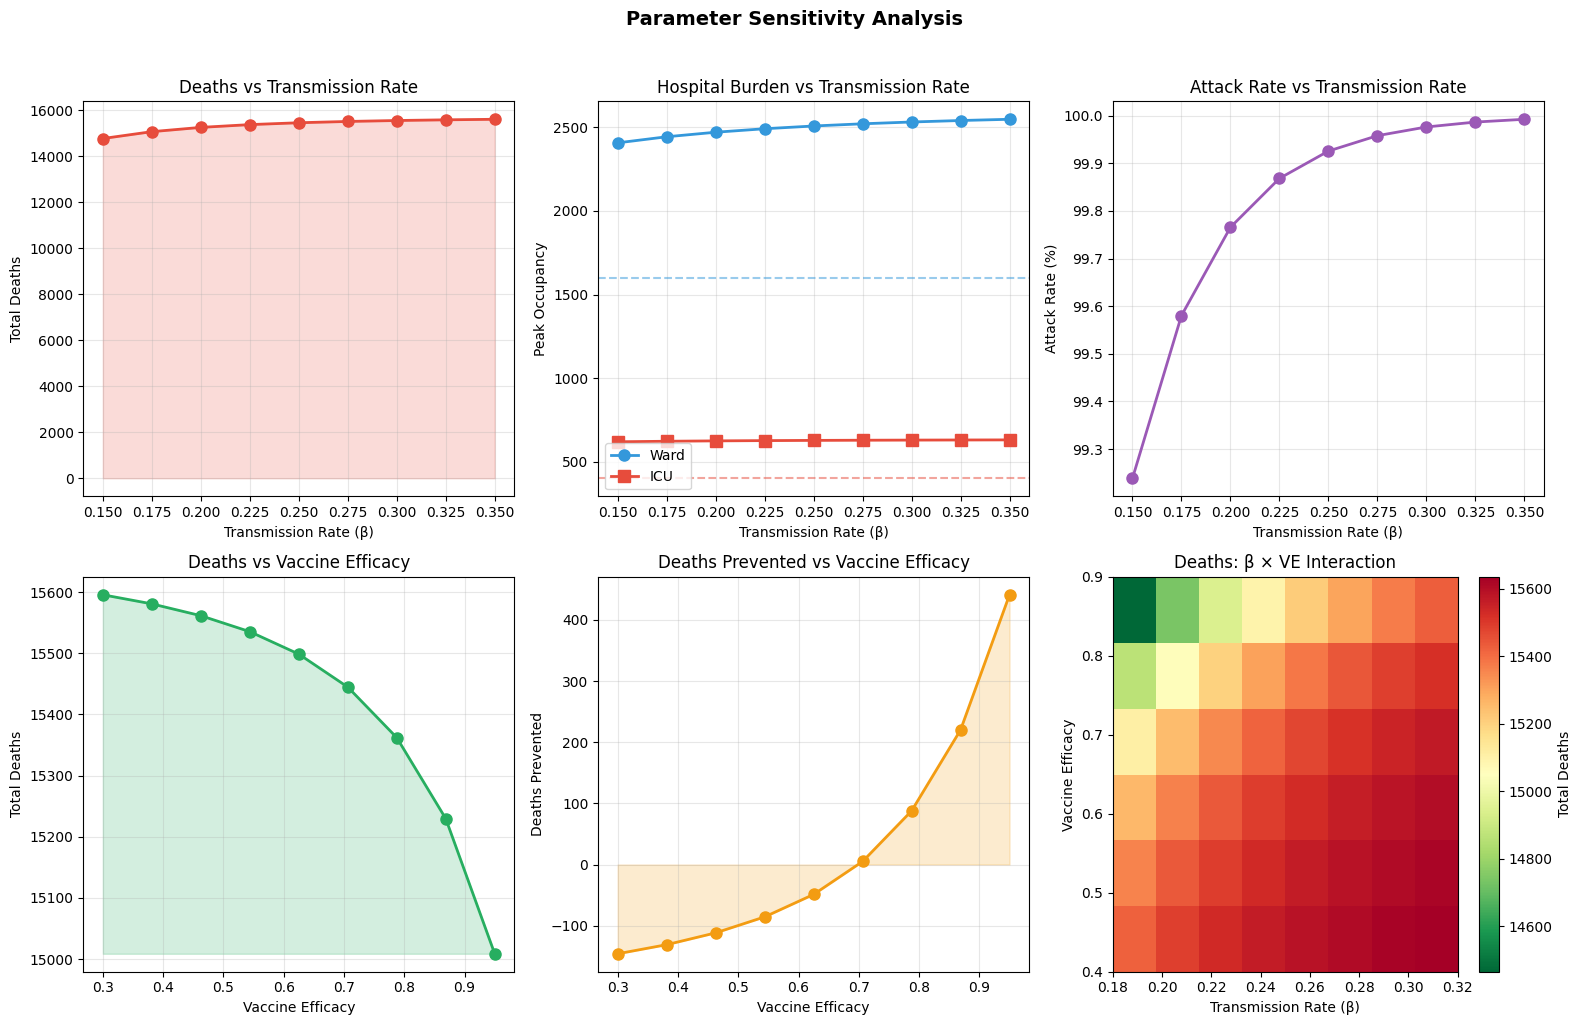

In [17]:
# Visualize sensitivity analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Deaths vs Beta
ax = axes[0, 0]
ax.plot(beta_sensitivity['beta'], beta_sensitivity['deaths'], 'o-', 
        color='#e74c3c', linewidth=2, markersize=8)
ax.fill_between(beta_sensitivity['beta'], 0, beta_sensitivity['deaths'], alpha=0.2, color='#e74c3c')
ax.set_xlabel('Transmission Rate (β)')
ax.set_ylabel('Total Deaths')
ax.set_title('Deaths vs Transmission Rate')
ax.grid(True, alpha=0.3)

# Plot 2: Peak Hospital vs Beta
ax = axes[0, 1]
ax.plot(beta_sensitivity['beta'], beta_sensitivity['peak_ward'], 'o-', 
        color='#3498db', linewidth=2, markersize=8, label='Ward')
ax.plot(beta_sensitivity['beta'], beta_sensitivity['peak_icu'], 's-', 
        color='#e74c3c', linewidth=2, markersize=8, label='ICU')
ax.axhline(y=ward_capacity, color='#3498db', linestyle='--', alpha=0.5)
ax.axhline(y=icu_capacity, color='#e74c3c', linestyle='--', alpha=0.5)
ax.set_xlabel('Transmission Rate (β)')
ax.set_ylabel('Peak Occupancy')
ax.set_title('Hospital Burden vs Transmission Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Attack Rate vs Beta
ax = axes[0, 2]
ax.plot(beta_sensitivity['beta'], beta_sensitivity['attack_rate'], 'o-', 
        color='#9b59b6', linewidth=2, markersize=8)
ax.set_xlabel('Transmission Rate (β)')
ax.set_ylabel('Attack Rate (%)')
ax.set_title('Attack Rate vs Transmission Rate')
ax.grid(True, alpha=0.3)

# Plot 4: Deaths vs VE
ax = axes[1, 0]
ax.plot(ve_sensitivity['VE'], ve_sensitivity['deaths'], 'o-', 
        color='#27ae60', linewidth=2, markersize=8)
ax.fill_between(ve_sensitivity['VE'], min(ve_sensitivity['deaths']), ve_sensitivity['deaths'], 
                alpha=0.2, color='#27ae60')
ax.set_xlabel('Vaccine Efficacy')
ax.set_ylabel('Total Deaths')
ax.set_title('Deaths vs Vaccine Efficacy')
ax.grid(True, alpha=0.3)

# Plot 5: Deaths Prevented vs VE
ax = axes[1, 1]
ax.plot(ve_sensitivity['VE'], ve_sensitivity['prevented'], 'o-', 
        color='#f39c12', linewidth=2, markersize=8)
ax.fill_between(ve_sensitivity['VE'], 0, ve_sensitivity['prevented'], alpha=0.2, color='#f39c12')
ax.set_xlabel('Vaccine Efficacy')
ax.set_ylabel('Deaths Prevented')
ax.set_title('Deaths Prevented vs Vaccine Efficacy')
ax.grid(True, alpha=0.3)

# Plot 6: Combined sensitivity heatmap (beta x VE)
ax = axes[1, 2]
# Quick 2D sensitivity scan
beta_grid = np.linspace(0.18, 0.32, 8)
ve_grid = np.linspace(0.4, 0.9, 6)
deaths_matrix = np.zeros((len(ve_grid), len(beta_grid)))

for i, ve in enumerate(ve_grid):
    for j, beta in enumerate(beta_grid):
        res = simulate_master_hospital_model(
            beta_base=beta,
            age_params=config.AGE_PARAMS_DEFAULT,
            contact_matrix=config.CONTACT_MATRIX_DEFAULT,
            ward_capacity=ward_capacity,
            icu_capacity=icu_capacity,
            coverage=[0.3, 0.4, 0.7],
            VE=ve,
            age_pops=age_pops,
            Tmax=200
        )
        deaths_matrix[i, j] = sum(res['D'][a][-1] for a in range(3))

im = ax.imshow(deaths_matrix, cmap='RdYlGn_r', aspect='auto',
               extent=[beta_grid[0], beta_grid[-1], ve_grid[0], ve_grid[-1]],
               origin='lower')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Total Deaths')
ax.set_xlabel('Transmission Rate (β)')
ax.set_ylabel('Vaccine Efficacy')
ax.set_title('Deaths: β × VE Interaction')

plt.suptitle('Parameter Sensitivity Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Experiment 9: Contact Matrix Analysis

Examine how different mixing patterns (assortative vs homogeneous) affect epidemic dynamics and age-specific outcomes.

In [18]:
# ============================================
# Experiment 9: Contact Matrix Analysis
# ============================================

contact_matrices = {
    'Default (moderate assortative)': config.CONTACT_MATRIX_DEFAULT,
    'Homogeneous mixing': config.CONTACT_MATRIX_HOMOGENEOUS,
    'Strong assortative': config.CONTACT_MATRIX_ASSORTATIVE,
}

contact_results = {}
for name, matrix in contact_matrices.items():
    contact_results[name] = simulate_master_hospital_model(
        beta_base=0.25,
        age_params=config.AGE_PARAMS_DEFAULT,
        contact_matrix=matrix,
        ward_capacity=ward_capacity,
        icu_capacity=icu_capacity,
        coverage=[0.3, 0.4, 0.7],
        VE=0.7,
        age_pops=age_pops,
        Tmax=250,
        track_differential_mortality=True
    )

print("="*80)
print("CONTACT MATRIX COMPARISON")
print("="*80)
print(f"{'Matrix Type':<30} {'Deaths':>10} {'Peak Ward':>12} {'Peak ICU':>10}")
print("-"*80)
for name, res in contact_results.items():
    deaths = sum(res['D'][a][-1] for a in range(3))
    print(f"{name:<30} {deaths:>10.0f} {max(res['H_ward_total']):>12.0f} {max(res['H_icu_total']):>10.0f}")

print("\nDeaths by age group:")
print(f"{'Matrix Type':<30} {'Young':>10} {'Middle':>10} {'Elderly':>10}")
print("-"*80)
for name, res in contact_results.items():
    print(f"{name:<30} {res['D'][0][-1]:>10.0f} {res['D'][1][-1]:>10.0f} {res['D'][2][-1]:>10.0f}")

CONTACT MATRIX COMPARISON
Matrix Type                        Deaths    Peak Ward   Peak ICU
--------------------------------------------------------------------------------
Default (moderate assortative)      15450         2509        627
Homogeneous mixing                  15651         2589        638
Strong assortative                  15439         2488        626

Deaths by age group:
Matrix Type                         Young     Middle    Elderly
--------------------------------------------------------------------------------
Default (moderate assortative)        205       4860      10384
Homogeneous mixing                    211       4947      10492
Strong assortative                    196       4858      10384


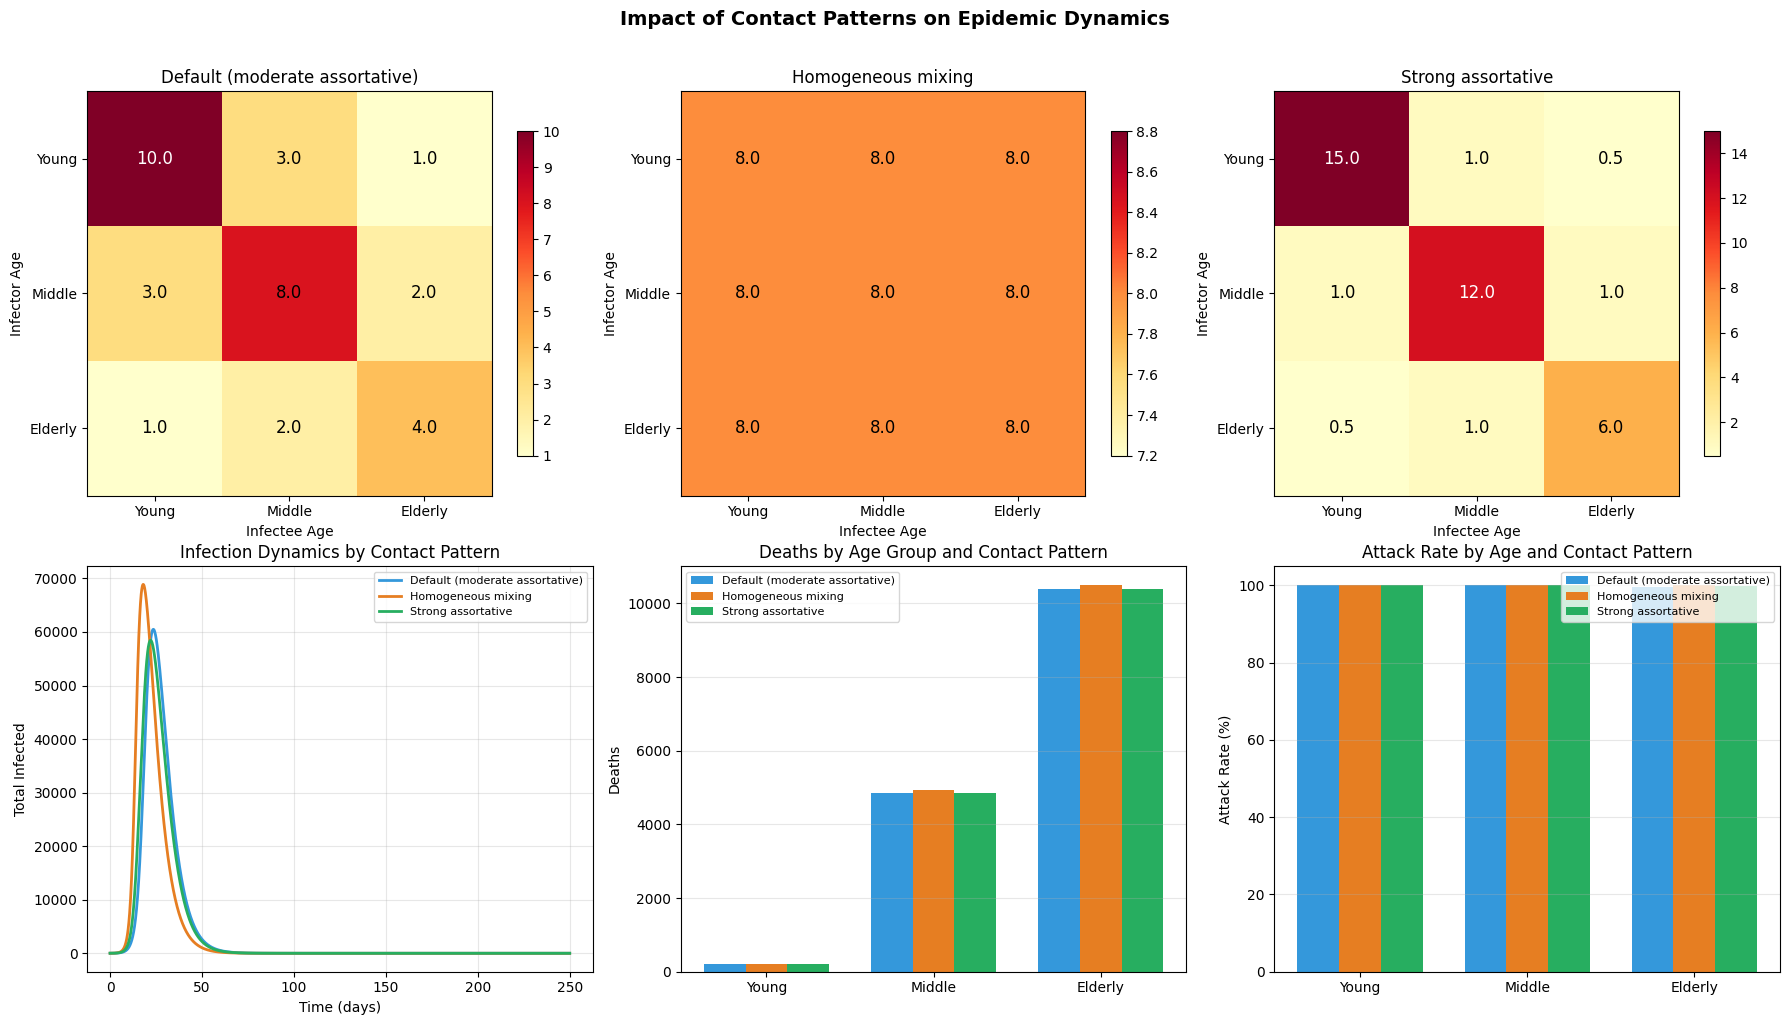

In [19]:
# Visualize contact matrix effects
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Contact matrices as heatmaps
for i, (name, matrix) in enumerate(contact_matrices.items()):
    ax = axes[0, i]
    im = ax.imshow(matrix, cmap='YlOrRd', aspect='equal')
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(config.AGE_LABELS_SHORT)
    ax.set_yticklabels(config.AGE_LABELS_SHORT)
    ax.set_xlabel('Infectee Age')
    ax.set_ylabel('Infector Age')
    ax.set_title(f'{name}')
    # Add values
    for ii in range(3):
        for jj in range(3):
            ax.text(jj, ii, f'{matrix[ii,jj]:.1f}', ha='center', va='center', 
                   color='white' if matrix[ii,jj] > 8 else 'black', fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)

# Row 2: Epidemic dynamics
colors = ['#3498db', '#e67e22', '#27ae60']
times = contact_results['Default (moderate assortative)']['times']

# Infections over time
ax = axes[1, 0]
for i, (name, res) in enumerate(contact_results.items()):
    I_total = [sum(res['I'][a][t] for a in range(3)) for t in range(len(times))]
    ax.plot(times, I_total, color=colors[i], linewidth=2, label=name)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Total Infected')
ax.set_title('Infection Dynamics by Contact Pattern')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Deaths by age for each matrix
ax = axes[1, 1]
x = np.arange(3)
width = 0.25
for i, (name, res) in enumerate(contact_results.items()):
    deaths = [res['D'][a][-1] for a in range(3)]
    ax.bar(x + i*width, deaths, width, label=name, color=colors[i])
ax.set_ylabel('Deaths')
ax.set_title('Deaths by Age Group and Contact Pattern')
ax.set_xticks(x + width)
ax.set_xticklabels(config.AGE_LABELS_SHORT)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Attack rate by age
ax = axes[1, 2]
for i, (name, res) in enumerate(contact_results.items()):
    attack_rates = [(age_pops[a] - res['S'][a][-1]) / age_pops[a] * 100 for a in range(3)]
    ax.bar(x + i*width, attack_rates, width, label=name, color=colors[i])
ax.set_ylabel('Attack Rate (%)')
ax.set_title('Attack Rate by Age and Contact Pattern')
ax.set_xticks(x + width)
ax.set_xticklabels(config.AGE_LABELS_SHORT)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Impact of Contact Patterns on Epidemic Dynamics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary and Key Findings

This notebook demonstrated the capabilities of the master SIXHRD model through 9 comprehensive experiments:

In [20]:
# ============================================
# Summary Statistics from All Experiments
# ============================================

print("="*70)
print("MASTER MODEL EXPERIMENTS - SUMMARY")
print("="*70)

print("""
EXPERIMENTS CONDUCTED:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. BASELINE SIMULATION
   - Established reference dynamics with age-structured Ward/ICU model
   - Demonstrated differential mortality tracking

2. POLICY INTERVENTIONS
   - Compared timing and intensity of lockdowns
   - Early intervention consistently outperformed delayed response
   
3. SEASONAL TRANSMISSION
   - 2-year simulations with varying seasonal amplitude
   - Stronger seasonality led to more pronounced waves

4. DIFFERENTIAL MORTALITY
   - Capacity constraints directly impact preventable deaths
   - Very limited capacity (25%) resulted in high preventable mortality

5. VACCINATION STRATEGIES
   - Elderly-priority strategies most effective for minimizing deaths
   - Transmission-blocking (young priority) reduced spread but not deaths

6. WANING IMMUNITY
   - 3-year endemic dynamics with age-specific waning
   - Fast waning leads to sustained waves and endemic equilibrium

7. COMPREHENSIVE PANDEMIC
   - Combined all features: seasonality, interventions, waning
   - Full 2-year dashboard visualization

8. SENSITIVITY ANALYSIS
   - β and VE are critical parameters
   - Non-linear relationship between transmission and outcomes

9. CONTACT MATRICES
   - Mixing patterns significantly affect age-specific outcomes
   - Homogeneous mixing spreads infection more evenly

KEY MODEL FEATURES DEMONSTRATED:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Separate Ward/ICU compartments with Hill function gating
✓ Age-structured transmission with contact matrices
✓ Differential mortality (treated vs untreated)
✓ Seasonal forcing of transmission
✓ Policy interventions (lockdowns)
✓ Waning immunity (age-specific)
✓ Vaccination with age-targeted coverage
""")

# Final model validation
print("\nMODEL VALIDATION:")
print("-"*50)
print("✓ Epidemic curves show expected rise-peak-decline")
print("✓ Hospital occupancy responds to capacity constraints")  
print("✓ Differential mortality tracks capacity overflow")
print("✓ Vaccination reduces transmission and mortality")
print("✓ Seasonal forcing creates periodic waves")
print("✓ Waning immunity enables endemic dynamics")

MASTER MODEL EXPERIMENTS - SUMMARY

EXPERIMENTS CONDUCTED:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. BASELINE SIMULATION
   - Established reference dynamics with age-structured Ward/ICU model
   - Demonstrated differential mortality tracking

2. POLICY INTERVENTIONS
   - Compared timing and intensity of lockdowns
   - Early intervention consistently outperformed delayed response

3. SEASONAL TRANSMISSION
   - 2-year simulations with varying seasonal amplitude
   - Stronger seasonality led to more pronounced waves

4. DIFFERENTIAL MORTALITY
   - Capacity constraints directly impact preventable deaths
   - Very limited capacity (25%) resulted in high preventable mortality

5. VACCINATION STRATEGIES
   - Elderly-priority strategies most effective for minimizing deaths
   - Transmission-blocking (young priority) reduced spread but not deaths

6. WANING IMMUNITY
   - 3-year endemic dynamics with age-specific waning
   - Fast waning leads to sustained waves and